# Causal Argumentation Framework
## Date: 28 May 2026

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import os, random
import pydot
from sklearn.model_selection import KFold
from collections import Counter
from causallearn.utils.cit import fisherz
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.Endpoint import Endpoint
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.GraphUtils import GraphUtils
os.environ['PYTHONHASHSEED'] = '42'  
random.seed(42)                       
np.random.seed(42)                    

c:\Users\hachimi\Documents\GitHub\causal_argumentation_remake_DAP301m\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helper methods

In [2]:


def _unwrap_graph(result):
    try:
        return result.G
    except Exception:
        return result[0] if isinstance(result, (list, tuple)) else result

def _ensure_numeric(df: pd.DataFrame, cols):
    out = {}
    for c in cols:
        s = df[c]
        if pd.api.types.is_numeric_dtype(s):
            out[c] = s
        else:
            codes, _ = pd.factorize(s, sort=True)
            out[c] = pd.Series(codes, index=s.index)
    return pd.DataFrame(out)


def define_tiers(tier_groups):
    """
    Map manual tier groups to a per-feature tier index.
    """
    feature_tiers = {}
    for tier, feats in tier_groups.items():
        for feat in feats:
            if feat in feature_tiers:
                raise ValueError(f"Feature '{feat}' assigned to multiple tiers.")
            feature_tiers[feat] = int(tier)
    return feature_tiers

def ensure_all_tiered(feature_tiers, features, outcome):
    missing = [f for f in list(features) + [outcome] if f not in feature_tiers]
    if missing:
        raise ValueError(f"Missing tier assignment for: {missing}")

def map_dummy_tiers(encoding_groups, feature_tiers, col_names):
    """
    Assign tiers to encoded columns based on their parent feature.
    """
    col_tiers = {}
    for parent, cols in (encoding_groups or {}).items():
        if parent not in feature_tiers:
            continue
        # Inherit the tier from the parent feature; no string matching needed.
        for c in cols:
            col_tiers[c] = feature_tiers[parent]
    for c in col_names:
        if c not in col_tiers and c in feature_tiers:
            col_tiers[c] = feature_tiers[c]
    missing = [c for c in col_names if c not in col_tiers]
    if missing:
        raise ValueError(f"Missing tier assignment for encoded columns: {missing}")
    return col_tiers

def build_background_knowledge(col_names, col_tiers):
    bk = BackgroundKnowledge()
    # BackgroundKnowledge expects Node objects, not strings.
    nodes = {name: GraphNode(name) for name in col_names}
    for a in col_names:
        ta = col_tiers[a]
        for b in col_names:
            if a == b:
                continue
            tb = col_tiers[b]
            if ta > tb:
                bk.add_forbidden_by_node(nodes[a], nodes[b])
    return bk


def remove_ambiguous_same_tier_edges(graph, col_tiers, prefix_sep="_", forbid_same_prefix=True, bk=None):
    if not col_tiers:
        return
    
    from causallearn.graph.Endpoint import Endpoint  # Ensure Endpoint is imported
    nodes = list(graph.get_nodes())
    
    for i, a in enumerate(nodes):
        name_a = a.get_name()
        ta = col_tiers.get(name_a)
        if ta is None:
            continue
            
        for b in nodes[i + 1:]:
            name_b = b.get_name()
            tb = col_tiers.get(name_b)
            if tb is None:
                continue
                
            # Get the edge between a and b, if any
            edge = graph.get_edge(a, b)
            if edge is None:
                edge = graph.get_edge(b, a)
            if edge is None:
                continue
                
            # Extract the root feature name (e.g. pclass_1 -> pclass, sex_female -> sex)
            root_a = name_a.split(prefix_sep)[0]
            root_b = name_b.split(prefix_sep)[0]
            
            # ============================================================
            # SAME-ROOT RULE CHECK (FORBID SAME ROOT) - HIGHEST PRIORITY
            # ============================================================
            if forbid_same_prefix and root_a == root_b:
                try:
                    graph.remove_edge(edge)
                    continue  # Removed same-root edge, skip the checks below
                except Exception:
                    pass

            # ============================================================
            # RULE 1: IF SAME TIER (adjusted as requested)
            # ============================================================
            if ta == tb:
                # Allow same-tier links freely if they have different roots.
                # Do not remove edges with circle endpoints here anymore.
                pass
                        
            # ============================================================
            # RULE 2: IF DIFFERENT TIERS (keep the top-down direction constraint)
            # ============================================================
            else:
                # 1. Identify source (lower tier) and target (higher tier)
                source_node = a if ta < tb else b
                target_node = b if ta < tb else a
                
                # 2. Enforce the downstream arrow direction
                if edge.get_node1() == source_node:
                    esource = edge.get_endpoint1()
                    edge.set_endpoint2(Endpoint.ARROW)  # Downstream node must be '>'
                    if esource != Endpoint.CIRCLE:
                        edge.set_endpoint1(Endpoint.TAIL)  # Upstream node must be '-' or 'o'
                else:
                    esource = edge.get_endpoint2()
                    edge.set_endpoint1(Endpoint.ARROW)  # Downstream node must be '>'
                    if esource != Endpoint.CIRCLE:
                        edge.set_endpoint2(Endpoint.TAIL)  # Upstream node must be '-' or 'o'
def merge_k_orientations(list_of_edges, k, rule="majority"):
    """
    Merge edges from K BAF graphs (from K folds) using a voting rule.
    This version keeps the most frequent orientation and resolves ties.
    """
    from collections import Counter
    dir_counts = Counter()
    for edges in list_of_edges:
        for (a, b) in edges:
            dir_counts[(a, b)] += 1

    merged = {}
    # Collect all unique nodes that appear across all K graphs
    nodes = set([a for edges in list_of_edges for a, _ in edges] + 
                [b for edges in list_of_edges for _, b in edges])
    
    pairs = set()
    for a in nodes:
        for b in nodes:
            if a < b:
                pairs.add((a, b))
                
    for a, b in pairs:
        ab = dir_counts.get((a, b), 0)
        ba = dir_counts.get((b, a), 0)
        none_edge = k - ab - ba  # Frequency of no edge between a and b
        
        if rule == "intersection":
            if ab == k: merged[(a, b)] = 1
            if ba == k: merged[(b, a)] = 1
        elif rule == "union":
            if ab > 0: merged[(a, b)] = 1
            if ba > 0: merged[(b, a)] = 1
        elif rule == "highest_freq":
            # Take the highest frequency among the 3 states
            max_freq = max(ab, ba, none_edge)
            
            # --- CLEAR WINNER CASE (NO TIE) ---
            if ab == max_freq and ab > ba and ab > none_edge:
                merged[(a, b)] = 1
            elif ba == max_freq and ba > ab and ba > none_edge:
                merged[(b, a)] = 1
                
            # --- TIE CASE ---
            elif max_freq > 0:
                # Tie 1 & 2: tie between one specific direction (A->B or B->A) and no edge
                if ab == max_freq and none_edge == max_freq:
                    merged[(a, b)] = 1  # Optimistic: keep A->B
                elif ba == max_freq and none_edge == max_freq:
                    merged[(b, a)] = 1  # Optimistic: keep B->A
                    
                # Tie 3: tie between A->B and B->A (two-way conflict)
                elif ab == max_freq and ba == max_freq:
                    # Conservative: do not add any edge to the merged dictionary to avoid cycles
                    pass
        else:  # majority (default legacy rule)
            threshold = k / 2.0
            if ab > ba and ab > threshold:
                merged[(a, b)] = 1
            elif ba > ab and ba > threshold:
                merged[(b, a)] = 1
                
    return set(merged.keys())

def k_fold_baf_discovery(df, features, outcome, categorical_features, k_splits=5,
                         entropy_binning_config=None, binarize_counts=('sibsp', 'parch'),
                         algo="pc", alpha=0.01, merge_rule="majority",
                         unified_dummy_noise=0.0, depth=-1,
                         tier_groups=None, feature_tiers=None,
                         output_dir: str = None, output_prefix: str = "discovery"):
    """
    Wrapper: run K-fold, produce K graphs, then merge them into one final BAF graph.
    Returns the same structure as the original run_dual_and_merge_with_unified function.
    """
    kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)
    list_of_group_edges = []
    
    print(f"Starting {k_splits}-Fold Causal Discovery...")
    
    # 1. Run K-fold and collect K edge lists
    for fold, (train_index, _) in enumerate(kf.split(df), 1):
        print(f"--- Building BAF graph for Fold {fold}/{k_splits} ---")
        df_train = df.iloc[train_index].copy()
        
        # Run causal discovery on the training split (K-1 folds worth of data)
        merged_res_fold, merged_group_edges, dfU_fold, enc_groups_full_fold, run1, run2 = \
            run_dual_and_merge_with_unified(
                df_train, features, outcome, categorical_features,
                entropy_binning_config=entropy_binning_config, binarize_counts=binarize_counts,
                algo=algo, alpha=alpha, merge_rule=merge_rule,
                unified_dummy_noise=unified_dummy_noise, depth=depth,
                tier_groups=tier_groups, feature_tiers=feature_tiers
            )
        
        list_of_group_edges.append(merged_group_edges)

        # If user requested per-fold exports, write DOT/png for this fold (merged group + unified)
        if output_dir:
            try:
                os.makedirs(output_dir, exist_ok=True)
                # merged group-level graph for this fold
                export_group_graph_with_corr(
                    merged_group_edges,
                    dfU_fold,
                    enc_groups_full_fold,
                    f"{output_dir}/{output_prefix}_kfold_{fold}_merged_groups_{algo}_weighted.png",
                    title=f"K-Fold {fold} Merged Group Directions (corr = strongest pair)"
                )
                # unified encoded graph for this fold
                export_unified_graph_with_corr(
                    merged_res_fold,
                    f"{output_dir}/{output_prefix}_kfold_{fold}_final_unified_{algo}_weighted.png",
                    title=f"K-Fold {fold} Unified Encoded Graph (with correlations)"
                )
            except Exception as e:
                print(f"Warning: failed to export per-fold graphs for fold {fold}: {e}")
        
    print(f"Finished K-fold. Starting to merge {k_splits} graphs using rule '{merge_rule}'...")
    
    # 2. Merge the K results into one final edge set
    final_merged_group_edges = merge_k_orientations(list_of_group_edges, k=k_splits, rule=merge_rule)
    
    # 3. Prepare the encoding table on the FULL dataset to preserve later correlation analysis
    dfU, enc_groups_full = _prepare_unified_encoding(
        df, features, outcome, categorical_features,
        entropy_binning_config, binarize_counts, dummy_noise=unified_dummy_noise,
    )

    encoded_nodes = list(dfU.columns)

    def group_cols(g):
        return enc_groups_full.get(g, [g])

    final_edges = []
    for (gA, gB) in final_merged_group_edges:
        for a in group_cols(gA):
            for b in group_cols(gB):
                if a != b:
                    final_edges.append((a, b))

    # Wrap the result in ResultShim - this is the object your BAF class can read
    merged_result = _ResultShim(final_edges, encoded_nodes, dfU, enc_groups_full)
    print("Finished merging BAF graph!")
    
    return merged_result, final_merged_group_edges, dfU, enc_groups_full


Data Clustering methods

In [3]:
def _entropy(p):
    if p <= 0.0 or p >= 1.0:
        return 0.0
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))

def _segment_entropy(y):
    y = np.asarray(y).astype(int)
    if len(y) == 0:
        return 0.0
    return _entropy(y.mean())

def _info_gain(y_parent, y_left, y_right):
    H_parent = _segment_entropy(y_parent)
    n = len(y_parent)
    wL = len(y_left) / n
    wR = len(y_right) / n
    return H_parent - (wL * _segment_entropy(y_left) + wR * _segment_entropy(y_right))

def _best_threshold_1d(x, y, min_bin_size=20):
    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]
    uniq = np.unique(x_sorted)
    if len(uniq) <= 1:
        return 0.0, None
    best_gain, best_thr = 0.0, None
    n = len(x_sorted)
    for i in range(min_bin_size, n - min_bin_size + 1):
        if x_sorted[i - 1] == x_sorted[i]:
            continue
        thr = (x_sorted[i - 1] + x_sorted[i]) / 2.0
        yL = y_sorted[:i]
        yR = y_sorted[i:]
        gain = _info_gain(y_sorted, yL, yR)
        if gain > best_gain:
            best_gain, best_thr = gain, thr
    return best_gain, best_thr

def _recursive_entropy_splits(x, y, max_bins=4, min_gain=0.005, min_bin_size=20):
    gain, thr = _best_threshold_1d(x, y, min_bin_size=min_bin_size)
    if thr is None or gain < min_gain or max_bins <= 1:
        return []
    left_idx = x <= thr
    right_idx = ~left_idx
    left_splits = _recursive_entropy_splits(
        x[left_idx], y[left_idx], max_bins=max_bins - 1, min_gain=min_gain, min_bin_size=min_bin_size
    )
    right_splits = _recursive_entropy_splits(
        x[right_idx], y[right_idx], max_bins=max_bins - 1, min_gain=min_gain, min_bin_size=min_bin_size
    )
    return sorted(left_splits + [thr] + right_splits)

def entropy_binning(series: pd.Series, y_binary: pd.Series,
                    max_bins=4, min_gain=0.005, min_bin_size=20):
    s_notna = series.dropna()
    if s_notna.empty:
        return [-np.inf, np.inf], [f"{series.name}:(all)"]
    s = s_notna.to_numpy(dtype=float)
    y = y_binary.loc[s_notna.index]
    if not pd.api.types.is_numeric_dtype(y):
        y = pd.Categorical(y).codes
    y = y.to_numpy(dtype=int)

    thresholds = _recursive_entropy_splits(
        s, y, max_bins=max_bins, min_gain=min_gain, min_bin_size=min_bin_size
    )
    if not thresholds:
        return [-np.inf, np.inf], [f"{series.name}:(all)"]
    edges = [-np.inf] + sorted(thresholds) + [np.inf]
    labels = [f"{series.name}[{edges[i]:.3f},{edges[i+1]:.3f})" for i in range(len(edges) - 1)]
    return edges, labels

STEP 1 - Causal Discovery

_run_discovery(df, features, outcome, alpha, categorical_features,
               entropy_binning_config, binarize_counts, baseline_strategy)


In [4]:
def _prepare_discovery_encoding(
    df, features, outcome,
    categorical_features=None,
    entropy_binning_config=None,
    binarize_counts=None,
    baseline_strategy="drop_first"
 ):
    """
    Encode data for causal discovery (PC/FCI) run.
    - df: full DataFrame
    - features: list of predictor columns
    - outcome: outcome/target column name
    - categorical_features: optional list; if None, auto-detect non-numeric
    - entropy_binning_config: dict, e.g. {'features': ['age'], 'max_bins':4,...}
    - binarize_counts: iterable of features to binarize (e.g. ['sibsp','parch'])
    - baseline_strategy: 'drop_first' or 'drop_last'
    """
    if categorical_features is None:
        categorical_features = [f for f in features if not pd.api.types.is_numeric_dtype(df[f])]

    bin_feats = set()
    bin_params = dict(max_bins=4, min_gain=0.005, min_bin_size=20)
    if entropy_binning_config:
        bin_feats = set(entropy_binning_config.get("features", []))
        for k in ("max_bins", "min_gain", "min_bin_size"):
            if k in entropy_binning_config:
                bin_params[k] = entropy_binning_config[k]

    y_bin = df[outcome] if pd.api.types.is_numeric_dtype(df[outcome]) else pd.Categorical(df[outcome]).codes
    y_bin = pd.Series(y_bin, index=df.index, name=outcome)

    df_processed = pd.DataFrame(index=df.index)
    encoding_groups = {}

    # 1) Entropy-binned numeric features
    for feat in features:
        if feat in bin_feats and pd.api.types.is_numeric_dtype(df[feat]):
            edges, labels = entropy_binning(
                df[feat], y_bin,
                max_bins=bin_params["max_bins"],
                min_gain=bin_params["min_gain"],
                min_bin_size=bin_params["min_bin_size"]
            )
            binned = pd.cut(df[feat], bins=edges, labels=labels, include_lowest=True)
            if baseline_strategy == "drop_last":
                d_all = pd.get_dummies(binned, prefix="", prefix_sep="", drop_first=False)
                dummies = d_all[sorted(d_all.columns)[:-1]]
            else:
                dummies = pd.get_dummies(binned, prefix="", prefix_sep="", drop_first=True)
            encoding_groups[feat] = list(dummies.columns)
            df_processed = pd.concat([df_processed, dummies], axis=1)

    # 2) Numeric features (optionally binarize)
    for feat in features:
        if feat not in categorical_features and feat not in bin_feats:
            if binarize_counts and feat in binarize_counts:
                df_processed[feat] = (df[feat].fillna(0) > 0).astype(int)
            else:
                df_processed[feat] = df[feat]

    # 3) Categorical one-hots
    for cat_feat in categorical_features:
        if baseline_strategy == "drop_last":
            d_all = pd.get_dummies(df[cat_feat], prefix=cat_feat, drop_first=False)
            keep = sorted(d_all.columns)[:-1]
            dummies = d_all[keep]
        else:
            dummies = pd.get_dummies(df[cat_feat], prefix=cat_feat, drop_first=True)
        encoding_groups[cat_feat] = list(dummies.columns)
        df_processed = pd.concat([df_processed, dummies], axis=1)

    df_processed[outcome] = y_bin

    # Ensure numeric matrix for CI tests; impute remaining NaNs.
    df_processed = df_processed.apply(pd.to_numeric, errors="coerce")
    if df_processed.isna().any().any():
        df_processed = df_processed.fillna(df_processed.mean(numeric_only=True))
        df_processed = df_processed.fillna(0.0)

    return df_processed.to_numpy(dtype=float), list(df_processed.columns), df_processed, encoding_groups


def _prepare_unified_encoding(
    df, features, outcome,
    categorical_features=None,
    entropy_binning_config=None,
    binarize_counts=None,
    dummy_noise=0.0
):
    """
    Encode for the final unified graph (keeps *all* bins/dummies).
    """
    if categorical_features is None:
        categorical_features = [f for f in features if not pd.api.types.is_numeric_dtype(df[f])]

    bin_feats = set()
    bin_params = dict(max_bins=4, min_gain=0.005, min_bin_size=20)
    if entropy_binning_config:
        bin_feats = set(entropy_binning_config.get("features", []))
        for k in ("max_bins", "min_gain", "min_bin_size"):
            if k in entropy_binning_config:
                bin_params[k] = entropy_binning_config[k]

    y_bin = df[outcome] if pd.api.types.is_numeric_dtype(df[outcome]) else pd.Categorical(df[outcome]).codes
    y_bin = pd.Series(y_bin, index=df.index, name=outcome)

    dfU = pd.DataFrame(index=df.index)
    enc_groups_full = {}

    # 1) Entropy-binned numeric features
    for feat in features:
        if feat in bin_feats and pd.api.types.is_numeric_dtype(df[feat]):
            edges, labels = entropy_binning(
                df[feat], y_bin,
                max_bins=bin_params["max_bins"],
                min_gain=bin_params["min_gain"],
                min_bin_size=bin_params["min_bin_size"]
            )
            binned = pd.cut(df[feat], bins=edges, labels=labels, include_lowest=True)
            dummies = pd.get_dummies(binned, prefix="", prefix_sep="", drop_first=False)
            enc_groups_full[feat] = list(dummies.columns)
            dfU = pd.concat([dfU, dummies], axis=1)

    # 2) Numeric features (optionally binarize)
    for feat in features:
        if feat not in categorical_features and feat not in bin_feats:
            if binarize_counts and feat in binarize_counts:
                dfU[feat] = (df[feat].fillna(0) > 0).astype(int)
                enc_groups_full.setdefault(feat, [feat])
            else:
                dfU[feat] = df[feat]

    # 3) Categorical features (keep all)
    for cat_feat in categorical_features:
        dummies = pd.get_dummies(df[cat_feat], prefix=cat_feat, drop_first=False)
        enc_groups_full[cat_feat] = list(dummies.columns)
        dfU = pd.concat([dfU, dummies], axis=1)

    dfU[outcome] = df[outcome]
    return dfU, enc_groups_full


Step 1.2 : run discovery twice, merge group-level edges, build unified encoded graph

In [5]:


def _run_discovery(df, features, outcome, alpha, categorical_features,
                   entropy_binning_config, binarize_counts, baseline_strategy,
                   algo="pc", depth=-1, feature_tiers=None):
    data, col_names, df_processed, encoding_groups = _prepare_discovery_encoding(
        df, features, outcome, categorical_features,
        entropy_binning_config, binarize_counts, baseline_strategy
    )
    background_knowledge = None
    col_tiers = None
    if feature_tiers is not None:
        ensure_all_tiered(feature_tiers, features, outcome)
        col_tiers = map_dummy_tiers(encoding_groups, feature_tiers, col_names)
        background_knowledge = build_background_knowledge(col_names, col_tiers)
    if algo.lower() == "pc":
        res = pc(data, alpha=alpha, ci_test=fisherz, node_names=col_names,
                 background_knowledge=background_knowledge, depth=depth)
    else:
        res = fci(data, alpha=alpha, ci_test=fisherz, node_names=col_names,
                  background_knowledge=background_knowledge, depth=depth,
                  verbose=False, show_progress=False)
    graph = _unwrap_graph(res)
    if algo.lower() != "pc" and col_tiers is not None:
        remove_ambiguous_same_tier_edges(graph, col_tiers)

    if hasattr(res, '__dict__'):
        res._processed_df = df_processed
        res._encoding_groups = encoding_groups
    else:
        class ResultWrapper:
            def __init__(self, original, dfp, groups):
                self.G = _unwrap_graph(original)
                self._processed_df = dfp
                self._encoding_groups = groups
        res = ResultWrapper(res, df_processed, encoding_groups)
    return res

def _column_to_group_map(encoding_groups, features, outcome):
    col2group = {}
    for g, cols in (encoding_groups or {}).items():
        for c in cols:
            col2group[c] = g
    for g in features + [outcome]:
        col2group.setdefault(g, g)
    return col2group

def _extract_group_edges(cg_result, features, outcome):
    G = _unwrap_graph(cg_result)
    groups = getattr(cg_result, '_encoding_groups', {})
    col2group = _column_to_group_map(groups, features, outcome)
    group_edges = set()
    for n in G.get_nodes():
        for ch in G.get_children(n):
            src = col2group.get(n.get_name(), n.get_name())
            dst = col2group.get(ch.get_name(), ch.get_name())
            if src != dst:
                group_edges.add((src, dst))
    return group_edges

def merge_orientations(edges1, edges2, rule="majority"):
    dir_counts = {}
    for (a, b) in edges1:
        dir_counts[(a, b)] = dir_counts.get((a, b), 0) + 1
    for (a, b) in edges2:
        dir_counts[(a, b)] = dir_counts.get((a, b), 0) + 1

    merged = {}
    nodes = set([a for a, _ in dir_counts] + [b for _, b in dir_counts])
    pairs = set()
    for a in nodes:
        for b in nodes:
            if a < b:
                pairs.add((a, b))
    for a, b in pairs:
        ab = dir_counts.get((a, b), 0)
        ba = dir_counts.get((b, a), 0)
        if rule == "intersection":
            if ab == 2:
                merged[(a, b)] = 1
            if ba == 2:
                merged[(b, a)] = 1
        elif rule == "union":
            if ab > 0:
                merged[(a, b)] = 1
            if ba > 0:
                merged[(b, a)] = 1
        else:  # majority
            if ab > ba and ab > 0:
                merged[(a, b)] = 1
            if ba > ab and ba > 0:
                merged[(b, a)] = 1
    return set(merged.keys())

class _SimpleNode:
    def __init__(self, name):
        self._n = name
    def get_name(self):
        return self._n

class _SimpleGraph:
    def __init__(self, edges, nodes):
        self._nodes = {n: _SimpleNode(n) for n in nodes}
        self._children = {n: set() for n in nodes}
        for a, b in edges:
            if a in self._nodes and b in self._nodes and a != b:
                self._children[a].add(b)
    def get_nodes(self):
        return list(self._nodes.values())
    def get_children(self, node):
        return [self._nodes[c] for c in self._children.get(node.get_name(), [])]
    def get_node(self, name):
        return self._nodes.get(name, None)

class _ResultShim:
    def __init__(self, edges, nodes, df_processed, encoding_groups):
        self.G = _SimpleGraph(edges, nodes)
        self._processed_df = df_processed
        self._encoding_groups = encoding_groups

def run_dual_and_merge_with_unified(df, features, outcome, categorical_features,
                                    entropy_binning_config=None, binarize_counts=('sibsp', 'parch'),
                                    algo="pc", alpha=0.01, merge_rule="majority",
                                    unified_dummy_noise=0.0, depth=-1,
                                    tier_groups=None, feature_tiers=None):
    if feature_tiers is None and tier_groups is not None:
        feature_tiers = define_tiers(tier_groups)
    run1 = _run_discovery(df, features, outcome, alpha, categorical_features,
                          entropy_binning_config, binarize_counts, "drop_first", algo=algo, depth=depth,
                          feature_tiers=feature_tiers)
    run2 = _run_discovery(df, features, outcome, alpha, categorical_features,
                          entropy_binning_config, binarize_counts, "drop_last", algo=algo, depth=depth,
                          feature_tiers=feature_tiers)

    g1 = _extract_group_edges(run1, features, outcome)
    g2 = _extract_group_edges(run2, features, outcome)
    merged_group_edges = merge_orientations(g1, g2, rule=merge_rule)

    dfU, enc_groups_full = _prepare_unified_encoding(
        df, features, outcome, categorical_features,
        entropy_binning_config, binarize_counts, dummy_noise=unified_dummy_noise,
    )

    encoded_nodes = list(dfU.columns)

    def group_cols(g):
        return enc_groups_full.get(g, [g])

    final_edges = []
    for (gA, gB) in merged_group_edges:
        for a in group_cols(gA):
            for b in group_cols(gB):
                if a != b:
                    final_edges.append((a, b))

    merged_result = _ResultShim(final_edges, encoded_nodes, dfU, enc_groups_full)
    return merged_result, merged_group_edges, dfU, enc_groups_full, run1, run2


Unified graphs

In [6]:
import os
import shutil

import networkx as nx
import matplotlib.pyplot as plt

def _graphviz_available():
    return shutil.which("dot") is not None

def _write_dot_fallback(dot_obj, filename: str):
    out_dir = os.path.dirname(filename)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    dot_path = f"{os.path.splitext(filename)[0]}.dot"
    with open(dot_path, "w", encoding="utf-8") as f:
        f.write(dot_obj.to_string())
    print(f"Graphviz not found. Saved DOT instead: {dot_path}")

def _edge_style_from_r(edge_obj, r, same_group=False):
    if same_group:
        edge_obj.set_style("dotted")
        edge_obj.set_color("#c62828")
    else:
        col = "#2e7d32" if r >= 0 else "#c62828"
        edge_obj.set_color(col)
        if abs(r) < 0.10:
            edge_obj.set_style("dashed")
    edge_obj.set_penwidth(str(1.0 + 4.0 * min(abs(r), 1.0)))

def _render_causallearn_graph_networkx(res, filename: str, title="Causal Discovery Graph"):
    G = _unwrap_graph(res)
    names = [n.get_name() for n in G.get_nodes()]
    df_for_corr = getattr(res, "_processed_df", None)
    if df_for_corr is None:
        raise ValueError("Result missing _processed_df for correlation labeling.")
    enc_groups = getattr(res, "_encoding_groups", {})
    col_to_group = {c: g for g, cols in enc_groups.items() for c in cols}

    df_num = _ensure_numeric(df_for_corr, names)
    corr = df_num.corr(method="pearson")

    graph = nx.DiGraph()
    graph.add_nodes_from(names)

    edge_specs = []
    for node in G.get_nodes():
        src = node.get_name()
        children = G.get_children(node)
        for child in children:
            dst = child.get_name()
            same_group = (col_to_group.get(src) is not None and
                          col_to_group.get(src) == col_to_group.get(dst))
            if same_group:
                r = -1.0
            else:
                r = np.nan
                if src in corr.index and dst in corr.columns:
                    r = float(corr.loc[src, dst])
                elif dst in corr.index and src in corr.columns:
                    r = float(corr.loc[dst, src])
            if same_group:
                color = "#c62828"
                style = "dotted"
                label = "-1.000"
            elif pd.isna(r):
                color = "#9e9e9e"
                style = "dashed"
                label = None
            else:
                color = "#2e7d32" if r >= 0 else "#c62828"
                style = "dashed" if abs(r) < 0.10 else "solid"
                label = f" {r:+.3f} "
            width = 1.0 + 4.0 * min(abs(r), 1.0) if not pd.isna(r) else 1.2
            edge_specs.append((src, dst, color, style, width, label))
            graph.add_edge(src, dst)

    if len(names) > 1:
        pos = nx.spring_layout(graph, seed=42, k=1.4, iterations=60)
    else:
        pos = {name: (0.0, 0.0) for name in names}

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.axis("off")

    if pos:
        xs = [xy[0] for xy in pos.values()]
        ys = [xy[1] for xy in pos.values()]
        x_span = max(max(xs) - min(xs), 1.0)
        y_span = max(max(ys) - min(ys), 1.0)
    else:
        x_span = y_span = 1.0

    node_w = 0.20 * x_span / max(len(names), 1) ** 0.5
    node_h = 0.12 * y_span / max(len(names), 1) ** 0.5

    from matplotlib.patches import Ellipse
    for name, (x, y) in pos.items():
        ax.add_patch(Ellipse((x, y), width=node_w, height=node_h, facecolor="#eef5ff",
                             edgecolor="#424242", linewidth=1.5, zorder=2))
        ax.text(x, y, name, ha="center", va="center", fontsize=10, zorder=3)

    for src, dst, color, style, width, label in edge_specs:
        nx.draw_networkx_edges(
            graph, pos, edgelist=[(src, dst)], ax=ax,
            edge_color=color, width=width, style=style,
            arrows=True, arrowstyle="-|>", arrowsize=16,
            connectionstyle="arc3,rad=0.08", min_source_margin=10, min_target_margin=12
        )
        if label is not None and src in pos and dst in pos:
            x_mid = (pos[src][0] + pos[dst][0]) / 2.0
            y_mid = (pos[src][1] + pos[dst][1]) / 2.0
            ax.text(x_mid, y_mid, label, fontsize=10, color="#263238", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor="none"),
                    zorder=4)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved (networkx): {filename}")

def export_causallearn_graph_with_corr(res, filename: str):
    G = _unwrap_graph(res)
    names = [n.get_name() for n in G.get_nodes()]
    df_for_corr = getattr(res, "_processed_df", None)
    if df_for_corr is None:
        raise ValueError("Result missing _processed_df for correlation labeling.")
    enc_groups = getattr(res, "_encoding_groups", {})
    col_to_group = {c: g for g, cols in enc_groups.items() for c in cols}

    df_num = _ensure_numeric(df_for_corr, names)
    corr = df_num.corr(method="pearson")

    idx_to_name = {str(i): name for i, name in enumerate(names)}
    dot = GraphUtils.to_pydot(G)
    for edge in dot.get_edges():
        src_idx = str(edge.get_source()).strip('"').strip()
        dst_idx = str(edge.get_destination()).strip('"').strip()
        src = idx_to_name.get(src_idx, src_idx)
        dst = idx_to_name.get(dst_idx, dst_idx)

        same_group = (col_to_group.get(src) is not None and
                      col_to_group.get(src) == col_to_group.get(dst))
        if same_group:
            r = -1.0
        else:
            r = np.nan
            if src in corr.index and dst in corr.columns:
                r = float(corr.loc[src, dst])
            elif dst in corr.index and src in corr.columns:
                r = float(corr.loc[dst, src])

        if not pd.isna(r):
            edge.set_label(f" {r:+.3f} ")
            edge.set_fontsize("11")
            _edge_style_from_r(edge, r, same_group=same_group)

    dot_path = f"{os.path.splitext(filename)[0]}.dot"
    out_dir = os.path.dirname(filename)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    with open(dot_path, "w", encoding="utf-8") as f:
        f.write(dot.to_string())
    print(f"Saved DOT: {dot_path}")

    if _graphviz_available():
        try:
            dot.write_png(filename)
            print(f"Saved (corr-labeled): {filename}")
            return
        except Exception as exc:
            print(f"Graphviz PNG export failed, falling back to networkx: {exc}")

    _render_causallearn_graph_networkx(res, filename, title="Causal Discovery Graph")

def export_unified_graph_with_corr(merged_result, filename: str, title="Unified Encoded Graph"):
    G = merged_result.G
    nodes = [n.get_name() for n in G.get_nodes()]
    df_for_corr = getattr(merged_result, "_processed_df", None)
    if df_for_corr is None:
        raise ValueError("merged_result missing _processed_df for correlation labeling.")
    enc_groups = getattr(merged_result, "_encoding_groups", {})
    col_to_group = {c: g for g, cols in enc_groups.items() for c in cols}

    df_num = _ensure_numeric(df_for_corr, nodes)
    corr = df_num.corr(method="pearson")

    graph = pydot.Dot(graph_type='digraph', rankdir='LR', label=title, labelloc='t', fontsize='20')
    pd_nodes = {n: pydot.Node(n, shape='ellipse', fontsize='10') for n in nodes}
    for n, node in pd_nodes.items():
        graph.add_node(node)

    for n in G.get_nodes():
        for ch in G.get_children(n):
            a, b = n.get_name(), ch.get_name()
            same_group = (col_to_group.get(a) is not None and col_to_group.get(a) == col_to_group.get(b))
            if same_group:
                r = -1.0
            else:
                r = np.nan
                if a in corr.index and b in corr.columns:
                    r = float(corr.loc[a, b])
                elif b in corr.index and a in corr.columns:
                    r = float(corr.loc[b, a])
            e = pydot.Edge(pd_nodes[a], pd_nodes[b], arrowsize='0.8')
            if not pd.isna(r):
                e.set_label(f" {r:+.3f} ")
                e.set_fontsize("11")
                _edge_style_from_r(e, r, same_group=same_group)
            graph.add_edge(e)

    if not _graphviz_available():
        _write_dot_fallback(graph, filename)
        return

    graph.write_png(filename)
    print(f"Saved (corr-labeled): {filename}")

def export_group_graph_with_corr(group_edges, df_unified, enc_groups_full, filename: str,
                                 title="Merged Group Graph (corr = strongest pair)"):
    def members(g):
        return enc_groups_full.get(g, [g])

    nodesU = df_unified.columns.tolist()
    df_num = _ensure_numeric(df_unified, nodesU)
    corr = df_num.corr(method="pearson")

    nodes = sorted(set([a for a, _ in group_edges] + [b for _, b in group_edges]))
    graph = pydot.Dot(graph_type='digraph', rankdir='LR', label=title, labelloc='t', fontsize='20')
    pd_nodes = {n: pydot.Node(n, shape='box', style='rounded,filled', fillcolor='#eef5ff') for n in nodes}
    for n, node in pd_nodes.items():
        graph.add_node(node)

    for gA, gB in group_edges:
        best_r = 0.0
        best_pair = None
        for a in members(gA):
            for b in members(gB):
                if a not in corr.index or b not in corr.columns:
                    continue
                r = corr.loc[a, b]
                if pd.isna(r):
                    continue
                if abs(r) > abs(best_r):
                    best_r = r
                    best_pair = (a, b)
        e = pydot.Edge(pd_nodes[gA], pd_nodes[gB], arrowsize='0.9')
        if best_pair is not None:
            e.set_label(f" {best_r:+.3f} ")
            e.set_fontsize("11")
            _edge_style_from_r(e, float(best_r), same_group=False)
        else:
            e.set_style("dashed")
            e.set_color("#9e9e9e")
        graph.add_edge(e)

    if not _graphviz_available():
        _write_dot_fallback(graph, filename)
        return

    graph.write_png(filename)
    print(f"Saved (corr-labeled): {filename}")


In [7]:
import os
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pydot


def _write_dot_text(dot_obj, filename: str):
    out_dir = os.path.dirname(filename)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)
    dot_path = f"{os.path.splitext(filename)[0]}.dot"
    with open(dot_path, "w", encoding="utf-8") as f:
        f.write(dot_obj.to_string())
    print(f"Saved DOT: {dot_path}")
    return dot_path


def _draw_networkx_graph(nodes, edge_specs, filename: str, title: str):
    graph = nx.DiGraph()
    graph.add_nodes_from(nodes)
    for src, dst, _, _, _, _ in edge_specs:
        graph.add_edge(src, dst)

    if len(nodes) > 1:
        pos = nx.spring_layout(graph, seed=42, k=1.4, iterations=60)
    else:
        pos = {name: (0.0, 0.0) for name in nodes}

    fig, ax = plt.subplots(figsize=(14, 10))
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.axis("off")

    xs = [xy[0] for xy in pos.values()] if pos else [0.0]
    ys = [xy[1] for xy in pos.values()] if pos else [0.0]
    x_span = max(max(xs) - min(xs), 1.0)
    y_span = max(max(ys) - min(ys), 1.0)
    scale = max(len(nodes), 1) ** 0.5
    node_w = 0.20 * x_span / scale
    node_h = 0.12 * y_span / scale

    for name, (x, y) in pos.items():
        ax.add_patch(Ellipse((x, y), width=node_w, height=node_h, facecolor="#eef5ff",
                             edgecolor="#424242", linewidth=1.5, zorder=2))
        ax.text(x, y, name, ha="center", va="center", fontsize=10, zorder=3)

    for src, dst, color, style, width, label in edge_specs:
        nx.draw_networkx_edges(
            graph, pos, edgelist=[(src, dst)], ax=ax,
            edge_color=color, width=width, style=style,
            arrows=True, arrowstyle="-|>", arrowsize=16,
            connectionstyle="arc3,rad=0.08", min_source_margin=10, min_target_margin=12,
        )
        if label is not None and src in pos and dst in pos:
            x_mid = (pos[src][0] + pos[dst][0]) / 2.0
            y_mid = (pos[src][1] + pos[dst][1]) / 2.0
            ax.text(x_mid, y_mid, label, fontsize=10, color="#263238", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor="none"),
                    zorder=4)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved PNG: {filename}")


def _edge_spec_from_corr(r, same_group=False):
    if same_group:
        return "#c62828", "dotted", 1.0 + 4.0 * 1.0, "-1.000"
    if pd.isna(r):
        return "#9e9e9e", "dashed", 1.2, None
    color = "#2e7d32" if r >= 0 else "#c62828"
    style = "dashed" if abs(r) < 0.10 else "solid"
    width = 1.0 + 4.0 * min(abs(float(r)), 1.0)
    label = f" {float(r):+.3f} "
    return color, style, width, label


def _render_fold_result_networkx(res, filename: str, title="Causal Discovery Graph"):
    G = _unwrap_graph(res)
    names = [n.get_name() for n in G.get_nodes()]
    df_for_corr = getattr(res, "_processed_df", None)
    if df_for_corr is None:
        raise ValueError("Result missing _processed_df for correlation labeling.")
    enc_groups = getattr(res, "_encoding_groups", {})
    col_to_group = {c: g for g, cols in enc_groups.items() for c in cols}

    df_num = _ensure_numeric(df_for_corr, names)
    corr = df_num.corr(method="pearson")

    dot = pydot.Dot(graph_type="digraph", rankdir="LR", label=title, labelloc="t", fontsize="20")
    for n in names:
        dot.add_node(pydot.Node(n, shape="ellipse", fontsize="10"))

    edge_specs = []
    for node in G.get_nodes():
        src = node.get_name()
        for child in G.get_children(node):
            dst = child.get_name()
            same_group = (
                col_to_group.get(src) is not None and
                col_to_group.get(src) == col_to_group.get(dst)
            )
            if same_group:
                r = -1.0
            else:
                r = np.nan
                if src in corr.index and dst in corr.columns:
                    r = float(corr.loc[src, dst])
                elif dst in corr.index and src in corr.columns:
                    r = float(corr.loc[dst, src])
            color, style, width, label = _edge_spec_from_corr(r, same_group=same_group)
            edge_specs.append((src, dst, color, style, width, label))
            edge = pydot.Edge(pydot.Node(src), pydot.Node(dst), arrowsize="0.8")
            if label is not None:
                edge.set_label(label)
                edge.set_fontsize("11")
            if same_group:
                edge.set_style("dotted")
                edge.set_color("#c62828")
            elif not pd.isna(r):
                edge.set_color(color)
                if abs(r) < 0.10:
                    edge.set_style("dashed")
                edge.set_penwidth(str(width))
            dot.add_edge(edge)

    _write_dot_text(dot, filename)
    _draw_networkx_graph(names, edge_specs, filename, title)


def _render_unified_result_networkx(merged_result, filename: str, title="Unified Encoded Graph"):
    G = merged_result.G
    nodes = [n.get_name() for n in G.get_nodes()]
    df_for_corr = getattr(merged_result, "_processed_df", None)
    if df_for_corr is None:
        raise ValueError("merged_result missing _processed_df for correlation labeling.")
    enc_groups = getattr(merged_result, "_encoding_groups", {})
    col_to_group = {c: g for g, cols in enc_groups.items() for c in cols}

    df_num = _ensure_numeric(df_for_corr, nodes)
    corr = df_num.corr(method="pearson")

    dot = pydot.Dot(graph_type="digraph", rankdir="LR", label=title, labelloc="t", fontsize="20")
    for n in nodes:
        dot.add_node(pydot.Node(n, shape="ellipse", fontsize="10"))

    edge_specs = []
    for node in G.get_nodes():
        src = node.get_name()
        for child in G.get_children(node):
            dst = child.get_name()
            same_group = (
                col_to_group.get(src) is not None and
                col_to_group.get(src) == col_to_group.get(dst)
            )
            if same_group:
                r = -1.0
            else:
                r = np.nan
                if src in corr.index and dst in corr.columns:
                    r = float(corr.loc[src, dst])
                elif dst in corr.index and src in corr.columns:
                    r = float(corr.loc[dst, src])
            color, style, width, label = _edge_spec_from_corr(r, same_group=same_group)
            edge_specs.append((src, dst, color, style, width, label))
            edge = pydot.Edge(pydot.Node(src), pydot.Node(dst), arrowsize="0.8")
            if label is not None:
                edge.set_label(label)
                edge.set_fontsize("11")
            if same_group:
                edge.set_style("dotted")
                edge.set_color("#c62828")
            elif not pd.isna(r):
                edge.set_color(color)
                if abs(r) < 0.10:
                    edge.set_style("dashed")
                edge.set_penwidth(str(width))
            dot.add_edge(edge)

    _write_dot_text(dot, filename)
    _draw_networkx_graph(nodes, edge_specs, filename, title)


def _render_group_result_networkx(group_edges, df_unified, enc_groups_full, filename: str,
                                 title="Merged Group Graph (corr = strongest pair)"):
    def members(g):
        return enc_groups_full.get(g, [g])

    nodesU = df_unified.columns.tolist()
    df_num = _ensure_numeric(df_unified, nodesU)
    corr = df_num.corr(method="pearson")

    nodes = sorted(set([a for a, _ in group_edges] + [b for _, b in group_edges]))
    dot = pydot.Dot(graph_type="digraph", rankdir="LR", label=title, labelloc="t", fontsize="20")
    for n in nodes:
        dot.add_node(pydot.Node(n, shape="ellipse", fontsize="10"))

    edge_specs = []
    for gA, gB in group_edges:
        best_r = np.nan
        best_pair = None
        for a in members(gA):
            for b in members(gB):
                if a not in corr.index or b not in corr.columns:
                    continue
                r = corr.loc[a, b]
                if pd.isna(r):
                    continue
                if best_pair is None or abs(float(r)) > abs(float(best_r)):
                    best_r = float(r)
                    best_pair = (a, b)
        color, style, width, label = _edge_spec_from_corr(best_r, same_group=False)
        if best_pair is None:
            color, style, width, label = "#9e9e9e", "dashed", 1.2, None
        edge_specs.append((gA, gB, color, style, width, label))
        edge = pydot.Edge(pydot.Node(gA), pydot.Node(gB), arrowsize="0.9")
        if label is not None:
            edge.set_label(label)
            edge.set_fontsize("11")
        if best_pair is None:
            edge.set_style("dashed")
            edge.set_color("#9e9e9e")
        else:
            edge.set_color(color)
            if abs(best_r) < 0.10:
                edge.set_style("dashed")
            edge.set_penwidth(str(width))
        dot.add_edge(edge)

    _write_dot_text(dot, filename)
    _draw_networkx_graph(nodes, edge_specs, filename, title)


def export_causallearn_graph_with_corr(res, filename: str):
    _render_fold_result_networkx(res, filename, title="Causal Discovery Graph")


def export_unified_graph_with_corr(merged_result, filename: str, title="Unified Encoded Graph"):
    _render_unified_result_networkx(merged_result, filename, title=title)


def export_group_graph_with_corr(group_edges, df_unified, enc_groups_full, filename: str,
                                 title="Merged Group Graph (corr = strongest pair)"):
    _render_group_result_networkx(group_edges, df_unified, enc_groups_full, filename, title=title)


In [8]:
def _render_unified_result_networkx(merged_result, filename: str, title="Unified Encoded Graph"):
    G = merged_result.G
    nodes = [n.get_name() for n in G.get_nodes()]
    df_for_corr = getattr(merged_result, "_processed_df", None)
    if df_for_corr is None:
        raise ValueError("merged_result missing _processed_df for correlation labeling.")
    enc_groups = getattr(merged_result, "_encoding_groups", {})
    col_to_group = {c: g for g, cols in enc_groups.items() for c in cols}

    df_num = _ensure_numeric(df_for_corr, nodes)
    corr = df_num.corr(method="pearson")

    group_order = []
    for group_name in enc_groups.keys():
        if group_name not in group_order:
            group_order.append(group_name)
    if "num" in group_order:
        group_order = [g for g in group_order if g != "num"] + ["num"]
    order_map = {g: i for i, g in enumerate(group_order)}

    graph = nx.DiGraph()
    graph.add_nodes_from(nodes)

    edge_specs = []
    for node in G.get_nodes():
        src = node.get_name()
        for child in G.get_children(node):
            dst = child.get_name()
            same_group = (
                col_to_group.get(src) is not None and
                col_to_group.get(src) == col_to_group.get(dst)
            )
            if same_group:
                r = -1.0
            else:
                r = np.nan
                if src in corr.index and dst in corr.columns:
                    r = float(corr.loc[src, dst])
                elif dst in corr.index and src in corr.columns:
                    r = float(corr.loc[dst, src])

            if same_group:
                color, style, width, label = "#c62828", "dotted", 1.0 + 4.0, "-1.000"
            elif pd.isna(r):
                color, style, width, label = "#9e9e9e", "dashed", 1.2, None
            else:
                color = "#2e7d32" if r >= 0 else "#c62828"
                style = "dashed" if abs(r) < 0.10 else "solid"
                width = 1.0 + 4.0 * min(abs(r), 1.0)
                label = f" {r:+.3f} "

            edge_specs.append((src, dst, color, style, width, label))
            graph.add_edge(src, dst)

    for node in graph.nodes:
        root_group = col_to_group.get(node, node)
        graph.nodes[node]["subset"] = order_map.get(root_group, len(order_map))

    try:
        pos = nx.multipartite_layout(graph, subset_key="subset", align="horizontal", scale=4.0)
    except Exception:
        pos = nx.spring_layout(graph, seed=42, k=2.4, iterations=120)

    fig, ax = plt.subplots(figsize=(18, 12))
    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.axis("off")

    xs = [xy[0] for xy in pos.values()] if pos else [0.0]
    ys = [xy[1] for xy in pos.values()] if pos else [0.0]
    x_span = max(max(xs) - min(xs), 1.0)
    y_span = max(max(ys) - min(ys), 1.0)
    scale = max(len(nodes), 1) ** 0.5
    node_w = 0.22 * x_span / scale
    node_h = 0.13 * y_span / scale

    from matplotlib.patches import Ellipse
    for name, (x, y) in pos.items():
        ax.add_patch(Ellipse((x, y), width=node_w, height=node_h, facecolor="#eef5ff",
                             edgecolor="#424242", linewidth=1.6, zorder=2))
        ax.text(x, y, name, ha="center", va="center", fontsize=10, zorder=3)

    for src, dst, color, style, width, label in edge_specs:
        nx.draw_networkx_edges(
            graph, pos, edgelist=[(src, dst)], ax=ax,
            edge_color=color, width=width, style=style,
            arrows=True, arrowstyle="-|>", arrowsize=16,
            connectionstyle="arc3,rad=0.08", min_source_margin=10, min_target_margin=12,
        )
        if label is not None and src in pos and dst in pos:
            x_mid = (pos[src][0] + pos[dst][0]) / 2.0
            y_mid = (pos[src][1] + pos[dst][1]) / 2.0
            ax.text(x_mid, y_mid, label, fontsize=9.5, color="#263238", ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.18", facecolor="white", alpha=0.85, edgecolor="none"),
                    zorder=4)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved PNG: {filename}")


def export_unified_graph_with_corr(merged_result, filename: str, title="Unified Encoded Graph"):
    _render_unified_result_networkx(merged_result, filename, title=title)


 BAF and AF (with fixed generate_constellations)

In [9]:

class BAF:
    def __init__(self, result, df=None):
        graph = _unwrap_graph(result)
        self.arguments = [n.get_name() for n in graph.get_nodes()]
        if hasattr(result, '_processed_df'):
            df_for_corr = result._processed_df
        else:
            if df is None:
                raise ValueError("Must provide df")
            df_for_corr = df
        self.encoding_groups = getattr(result, '_encoding_groups', {})
        self.col_to_group = {c: g for g, cols in self.encoding_groups.items() for c in cols}
        df_num = _ensure_numeric(df_for_corr, self.arguments)
        self.corr_matrix = df_num.corr(method="pearson")

        self.supports, self.attacks = {}, {}
        for node in graph.get_nodes():
            for child in graph.get_children(node):
                src = node.get_name()
                dst = child.get_name()
                r = self._get_correlation(src, dst)
                if not pd.isna(r):
                    if r > 0:
                        self.supports[(src, dst)] = r
                    else:
                        self.attacks[(src, dst)] = abs(r)

    def _get_correlation(self, src, dst):
        g1 = self.col_to_group.get(src)
        g2 = self.col_to_group.get(dst)
        if g1 is not None and g2 is not None and g1 == g2:
            return -1.0
        try:
            return self.corr_matrix.loc[src, dst]
        except Exception:
            try:
                return self.corr_matrix.loc[dst, src]
            except Exception:
                return np.nan

    def to_classical_af(self, threshold=0.0, verbose=False,
                        enforce_exclusivity=True,
                        exclusivity_skip=('survived',),
                        exclusivity_weight=1.0):
        af_attacks = self.attacks.copy()
        working_supports = self.supports.copy()

        # support closure
        changed = True
        while changed:
            changed = False
            for (A, B), x in list(working_supports.items()):
                for (B2, C), y in list(working_supports.items()):
                    if B == B2 and A != C:
                        new_weight = x*y
                        if new_weight > threshold:
                            if (A, C) not in working_supports or working_supports[(A, C)] < new_weight:
                                working_supports[(A, C)] = new_weight
                                changed = True

        # support -> attack
        for (A, B), x in working_supports.items():
            for (B2, C), y in list(af_attacks.items()):
                if B == B2 and A != C:
                    new_weight = x*y
                    if new_weight > threshold and (A, C) not in af_attacks:
                        af_attacks[(A, C)] = new_weight

        # attack -> support-like attacks
        for (A, B), x in list(af_attacks.items()):
            for (C, B2), y in working_supports.items():
                if B == B2 and A != C:
                    new_weight = y
                    if new_weight > threshold and (C, A) not in af_attacks:
                        af_attacks[(C, A)] = new_weight

        af = AF(self.arguments, af_attacks)
        if enforce_exclusivity and getattr(self, "encoding_groups", None):
            skip = set(exclusivity_skip or ())
            groups = {g: cols for g, cols in self.encoding_groups.items() if g not in skip}
            af.add_mutual_exclusivity(groups, weight=exclusivity_weight)
        return af


class AF:
    def __init__(self, arguments, attacks):
        self.arguments = list(arguments)
        self.attacks = dict(attacks)

    def print_summary(self):
        print(f"\nClassical AF Summary:")
        print(f"  Arguments: {len(self.arguments)}")
        print(f"  Attack relations: {len(self.attacks)}")

    def to_apx_format(self, filename="framework.apx"):
        with open(filename, 'w') as f:
            for arg in self.arguments:
                f.write(f"arg({arg}).\n")
            f.write("\n")
            for (src, tgt), _ in self.attacks.items():
                f.write(f"att({src},{tgt}).\n")
        print(f"Exported APX format to: {filename}")
        return filename

    def to_tgf_format(self, filename="framework.tgf"):
        with open(filename, 'w') as f:
            for arg in self.arguments:
                f.write(f"{arg}\n")
            f.write("#\n")
            for (src, tgt), _ in self.attacks.items():
                f.write(f"{src} {tgt}\n")
        print(f"Exported TGF format to: {filename}")
        return filename

    def add_mutual_exclusivity(self, groups: dict, weight: float = 1.0):
        for _, cols in groups.items():
            cols = [c for c in cols if c in self.arguments]
            for i in range(len(cols)):
                for j in range(i + 1, len(cols)):
                    a, b = cols[i], cols[j]
                    self.attacks[(a, b)] = max(weight, self.attacks.get((a, b), 0.0))
                    self.attacks[(b, a)] = max(weight, self.attacks.get((b, a), 0.0))

    # Use helpers
    def _attacks(self, A, B):
        return (A, B) in self.attacks

    def _attackers_of(self, x):
        return {a for (a, b) in self.attacks if b == x}

    def _range_of(self, S):
        attacked = {b for (a, b) in self.attacks if a in S}
        return set(S) | attacked

    def _is_conflict_free(self, S):
        return all((a, b) not in self.attacks for a in S for b in S if a != b)

    def _defends(self, S, x):
        for a in self._attackers_of(x):
            if not any(self._attacks(b, a) for b in S):
                return False
        return True

    def _is_admissible(self, S):
        if not self._is_conflict_free(S):
            return False
        return all(self._defends(S, x) for x in S)

    def _all_admissible_sets(self, limit_nodes=22):
        U = list(self.arguments)
        n = len(U)
        if n > limit_nodes:
            k = max(10, min(14, n // 2))
            def k_subsets(iterable, kmax):
                it = list(iterable)
                for r in range(kmax + 1):
                    for comb in combinations(it, r):
                        yield set(comb)
            candidates = k_subsets(U, k)
        else:
            candidates = (set(c) for r in range(n + 1) for c in combinations(U, r))
        return [S for S in candidates if self._is_admissible(S)]

    def semistable_extensions(self):
        adm = self._all_admissible_sets()
        if not adm:
            return []
        ranges = [(S, len(self._range_of(S))) for S in adm]
        max_range = max(sz for _, sz in ranges)
        return [S for S, sz in ranges if sz == max_range]

    def compute_grounded_extension(self):
        unattacked = {a for a in self.arguments if not self._attackers_of(a)}
        S = set(unattacked)
        changed = True
        while changed:
            changed = False
            for a in self.arguments:
                if a in S:
                    continue
                if self._defends(S, a):
                    S.add(a)
                    changed = True
        return S

    def generate_constellations(self, top_k=None, threshold=0.1):
        significant = [((a, b), p) for (a, b), p in self.attacks.items() if abs(p) >= threshold]
        constellations = []
        m = len(significant)

        if m > 20:
            import random
            random.seed(42)
            samples = min(1000, 2 ** m)
            for _ in range(samples):
                active, prob = {}, 1.0
                for (edge, p) in significant:
                    if random.random() < abs(p):
                        active[edge] = p
                        prob *= abs(p)
                    else:
                        prob *= (1 - abs(p))
                constellations.append((AF(self.arguments, active), prob))
        else:
            for mask in range(2 ** m):
                active, prob = {}, 1.0
                for j, (edge, p) in enumerate(significant):
                    if mask & (1 << j):
                        active[edge] = p
                        prob *= abs(p)
                    else:
                        prob *= (1 - abs(p))
                constellations.append((AF(self.arguments, active), prob))

        constellations.sort(key=lambda x: -x[1])
        if top_k:
            constellations = constellations[:top_k]

        Z = sum(p for _, p in constellations)
        if Z > 0:
            constellations = [(af, p / Z) for af, p in constellations]

        print(f"\nGenerating constellations from {len(significant)} significant attacks "
              f"(threshold={threshold}); total kept={len(constellations)}")
        return constellations

    def _group_of(self, name, encoding_groups):
        for g, cols in (encoding_groups or {}).items():
            if name in cols:
                return g
        return None

    def _extension_respects_group_exclusivity(self, ext_set, encoding_groups):
        seen = {}
        for a in ext_set:
            g = self._group_of(a, encoding_groups)
            if g is None:
                continue
            if g in seen:
                return False
            seen[g] = a
        return True

    def compute_extensions_probability(self, semantics='semistable', top_k=100, threshold=0.15,
                                       require_one_of=None, exactly_one=False,
                                       enforce_group_exclusivity=True, encoding_groups=None):
        print(f"\n{'=' * 60}\nComputing {semantics} extensions with constellation approach\n{'=' * 60}")
        constellations = self.generate_constellations(top_k=top_k, threshold=threshold)

        def ok(ext_set):
            if require_one_of:
                count = sum(1 for a in require_one_of if a in ext_set)
                if exactly_one:
                    if count != 1:
                        return False
                else:
                    if count < 1:
                        return False
            if enforce_group_exclusivity and encoding_groups:
                if not self._extension_respects_group_exclusivity(ext_set, encoding_groups):
                    return False
            return True

        extension_probs, kept_mass = {}, 0.0
        for af, prob in constellations:
            if semantics == 'semistable':
                exts = af.semistable_extensions()
            else:
                exts = [af.compute_grounded_extension()]
            if not exts:
                continue
            share = prob / len(exts)
            used = False
            for ext in exts:
                if ok(ext):
                    extension_probs[frozenset(ext)] = extension_probs.get(frozenset(ext), 0.0) + share
                    used = True
            if used:
                kept_mass += prob

        if kept_mass > 0:
            for k in list(extension_probs.keys()):
                extension_probs[k] /= kept_mass
        else:
            print("WARNING: No extensions satisfied the constraint; returning empty result.")

        sorted_ext = sorted(extension_probs.items(), key=lambda x: -x[1])
        print(f"\nFound {len(sorted_ext)} unique extensions (after constraints)")
        for i, (ext, p) in enumerate(sorted_ext[:20], 1):
            print(f"  {i}. P={p:.4f}: {{{', '.join(sorted(ext))}}}")
        return dict(sorted_ext)

    def analyze_argument_acceptance(self, extension_probs):
        print(f"\n{'=' * 60}\nArgument Acceptance Probabilities\n{'=' * 60}")
        arg_probs = {arg: 0.0 for arg in self.arguments}
        for ext, prob in extension_probs.items():
            for arg in ext:
                arg_probs[arg] += prob
        ranked = sorted(arg_probs.items(), key=lambda x: -x[1])
        for arg, prob in ranked:
            bar = '█' * int(prob * 50)
            print(f"  {arg:20s} {prob:.4f} {bar}")
        return dict(ranked)

    def visualize(self, title="Classical AF", figsize=(12, 10), output_file=None, min_attack_weight=0.05):
        G = nx.DiGraph()
        G.add_nodes_from(self.arguments)
        plt.figure(figsize=figsize)
        pos = nx.spring_layout(G, seed=42, k=2, iterations=50)
        nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=2500, alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
        for (src, tgt), weight in self.attacks.items():
            if abs(weight) < min_attack_weight:
                continue
            nx.draw_networkx_edges(G, pos, [(src, tgt)],
                                   edge_color='red', width=1 + 3 * abs(weight),
                                   alpha=0.6, arrowsize=15, arrowstyle='->')
            mid_x = (pos[src][0] + pos[tgt][0]) / 2
            mid_y = (pos[src][1] + pos[tgt][1]) / 2
            plt.text(mid_x, mid_y, f'{weight:.2f}', fontsize=9, color='darkred',
                     ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        if output_file:
            plt.savefig(output_file, dpi=150, bbox_inches='tight')
            print(f"Saved AF visualization to: {output_file}")
        plt.show()
        return plt

    def visualize_filtered(self, title="Classical AF (filtered)", figsize=(12, 10), output_file=None,
                           min_attack_weight=0.05, encoding_groups=None, prefix_sep="_",
                           same_root_alpha=0.3, drop_same_root=False):
        group_map = {c: g for g, cols in (encoding_groups or {}).items() for c in cols}

        def _root(name):
            if group_map:
                grp = group_map.get(name)
                if grp is not None:
                    return grp
            if prefix_sep and prefix_sep in name:
                return name.rsplit(prefix_sep, 1)[0]
            return name

        G = nx.DiGraph()
        G.add_nodes_from(self.arguments)
        plt.figure(figsize=figsize)
        pos = nx.spring_layout(G, seed=42, k=2, iterations=50)
        nx.draw_networkx_nodes(G, pos, node_color='lightcoral', node_size=2500, alpha=0.9)
        nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')
        for (src, tgt), weight in self.attacks.items():
            if abs(weight) < min_attack_weight:
                continue
            same_root = _root(src) == _root(tgt)
            if same_root and drop_same_root:
                continue
            edge_alpha = same_root_alpha if same_root else 0.6
            edge_color = '#9e9e9e' if same_root else 'red'
            nx.draw_networkx_edges(
                G, pos, [(src, tgt)],
                edge_color=edge_color, width=1 + 3 * abs(weight),
                alpha=edge_alpha, arrowsize=15, arrowstyle='->'
            )
            if same_root:
                continue
            mid_x = (pos[src][0] + pos[tgt][0]) / 2
            mid_y = (pos[src][1] + pos[tgt][1]) / 2
            plt.text(mid_x, mid_y, f'{weight:.2f}', fontsize=9, color='darkred',
                     ha='center', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
        plt.title(title, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        if output_file:
            plt.savefig(output_file, dpi=150, bbox_inches='tight')
            print(f"Saved filtered AF visualization to: {output_file}")
        plt.show()
        return plt


def make_binary_sink(baf: BAF, sink='survived', zero='survived_0', one='survived_1'):
    args = [a for a in baf.arguments if a != sink] + [zero, one]
    new_supp, new_att = {}, {}

    # keep edges not touching sink
    for (A, B), w in baf.supports.items():
        if A != sink and B != sink:
            new_supp[(A, B)] = max(w, new_supp.get((A, B), 0.0))
    for (A, B), w in baf.attacks.items():
        if A != sink and B != sink:
            new_att[(A, B)] = max(w, new_att.get((A, B), 0.0))

    # edges into sink → into 'one' (support) and into 'zero' (attack)
    for (A, B), w in baf.supports.items():
        if B == sink:
            new_supp[(A, one)] = max(w, new_supp.get((A, one), 0.0))
            new_att[(A, zero)] = max(w, new_att.get((A, zero), 0.0))
    for (A, B), w in baf.attacks.items():
        if B == sink:
            new_supp[(A, zero)] = max(w, new_supp.get((A, zero), 0.0))
            new_att[(A, one)] = max(w, new_att.get((A, one), 0.0))

    enc = dict(getattr(baf, "encoding_groups", {}))
    enc[sink] = [zero, one]

    baf.arguments = args
    baf.supports = new_supp
    baf.attacks = new_att
    baf.encoding_groups = enc
    return baf

In [10]:
# ─────────────────────────────────────────────────────
# BAF Feature Importance: map encoded args → feature level
# ─────────────────────────────────────────────────────
import re

def baf_feature_importance(arg_acceptance, enc_groups_full, outcome_name, agg='max'):
    """
    Aggregate argument acceptance probabilities from encoded-column level
    back to original feature level.

    Parameters
    ----------
    arg_acceptance  : dict  {encoded_col: acceptance_prob}
    enc_groups_full : dict  {feature_name: [encoded_col, ...]}
    outcome_name    : str   e.g. 'num' or 'Outcome'
    agg             : 'max' | 'mean'

    Returns
    -------
    list of (feature, score) sorted descending
    """
    # Build reverse map: encoded_col → parent feature
    col_to_feat = {}
    for feat, cols in enc_groups_full.items():
        for col in cols:
            col_to_feat[col] = feat

    # Outcome columns to skip
    outcome_cols = {outcome_name, outcome_name + '_0', outcome_name + '_1'}

    feat_scores = {}
    for arg, prob in arg_acceptance.items():
        if arg in outcome_cols:
            continue
        feat = col_to_feat.get(arg, arg)   # fallback: use arg name itself
        if feat in outcome_cols:
            continue
        feat_scores.setdefault(feat, []).append(prob)

    if agg == 'max':
        aggregated = {feat: max(scores) for feat, scores in feat_scores.items()}
    else:
        aggregated = {feat: sum(scores)/len(scores) for feat, scores in feat_scores.items()}

    return sorted(aggregated.items(), key=lambda x: -x[1])


def reciprocal_rank_fusion(rankings, k=60):
    """
    Combine multiple ranked lists using Reciprocal Rank Fusion.

    Parameters
    ----------
    rankings : list of list-of-(feature, score) sorted desc
    k        : RRF constant (default 60)

    Returns
    -------
    list of (feature, rrf_score) sorted descending
    """
    scores = {}
    for ranking in rankings:
        for rank, (feat, _) in enumerate(ranking, start=1):
            scores[feat] = scores.get(feat, 0.0) + 1.0 / (k + rank)
    return sorted(scores.items(), key=lambda x: -x[1])


print('Helper functions loaded: baf_feature_importance(), reciprocal_rank_fusion()')


Helper functions loaded: baf_feature_importance(), reciprocal_rank_fusion()


## P- Value and random forest dataset heart - disease

Evaluate Features using P-value:
     Feature       P-Value
12      thal  1.241673e-18
2         cp  1.178284e-16
11        ca  1.372578e-15
9    oldpeak  2.159737e-14
7    thalach  2.239715e-14
8      exang  9.510884e-13
10     slope  3.630107e-10
1        sex  2.945690e-06
0        age  7.862868e-05
3   trestbps  8.054796e-03
6    restecg  8.331151e-03
4       chol  1.675878e-01
5        fbs  1.000000e+00


Evaluate Features using Random Forest (Feature Importances):
     Feature  Importance
7    thalach    0.123176
12      thal    0.120980
2         cp    0.119219
11        ca    0.117524
9    oldpeak    0.105544
0        age    0.101294
3   trestbps    0.074835
4       chol    0.072463
8      exang    0.053397
10     slope    0.048968
1        sex    0.031521
6    restecg    0.021432
5        fbs    0.009647


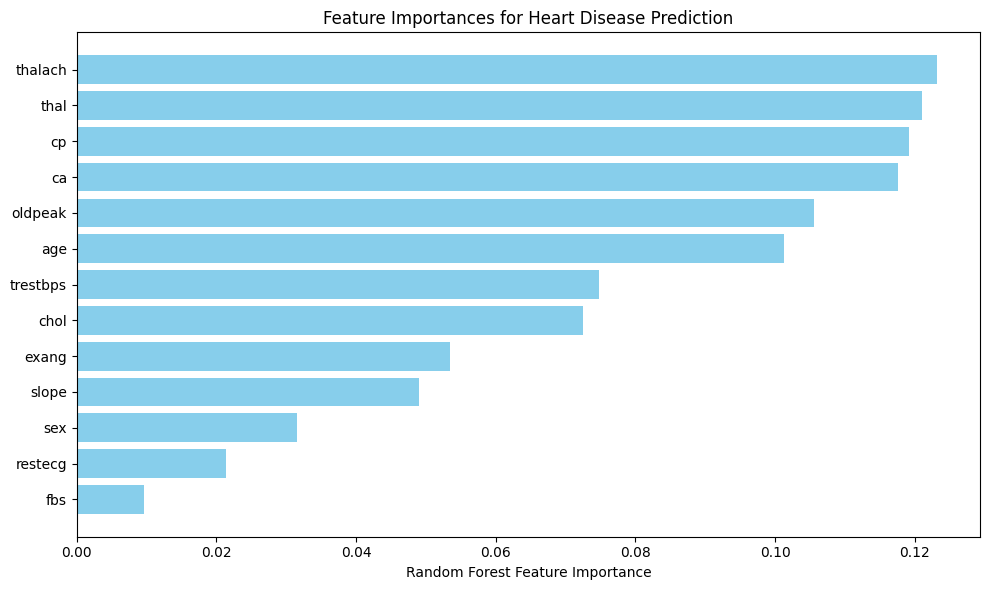

In [11]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Tải dữ liệu Heart Disease (ID 45) từ UCI
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

# Xử lý dữ liệu ban đầu
df = pd.concat([X, y], axis=1)
df['num'] = (df['num'] > 0).astype(int) # Chuyển bài toán thành phân loại nhị phân
df = df.dropna().reset_index(drop=True)
X_clean = df.drop(columns=['num'])
y_clean = df['num']

# 1. Đánh giá Feature bằng P-value
print("Evaluate Features using P-value:")
p_values = {}
# Phân loại biến categorical để tính Chi-square, còn lại tính T-test
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_features:
    if pd.api.types.is_float_dtype(df[col]):
        df[col] = df[col].astype(int)
for col in X_clean.columns:
    if col in categorical_features and col in X_clean.columns:
        # Kiểm định Chi-square cho biến phân loại
        contingency = pd.crosstab(X_clean[col], y_clean)
        chi2, p, dof, ex = stats.chi2_contingency(contingency)
        p_values[col] = p
    else:
        # Kiểm định T-test cho biến liên tục
        group0 = X_clean[y_clean == 0][col]
        group1 = X_clean[y_clean == 1][col]
        t_stat, p = stats.ttest_ind(group0, group1)
        p_values[col] = p

p_df = pd.DataFrame(list(p_values.items()), columns=['Feature', 'P-Value']).sort_values('P-Value')
print(p_df)
print("\n" + "="*50 + "\n")

# 2. Đánh giá Feature bằng Random Forest
print("Evaluate Features using Random Forest (Feature Importances):")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_clean, y_clean)

importances = pd.DataFrame({
    'Feature': X_clean.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print(importances)

# Vẽ biểu đồ mức độ quan trọng
plt.figure(figsize=(10, 6))
plt.barh(importances['Feature'][::-1], importances['Importance'][::-1], color='skyblue')
plt.xlabel('Random Forest Feature Importance')
plt.title('Feature Importances for Heart Disease Prediction')
plt.tight_layout()
plt.show()

## Heart - disease

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo

# ==========================================
# DATA LOADING & PREP (UCI Heart Disease)
# ==========================================
# Fetch dataset (ID 45)
heart_disease = fetch_ucirepo(id=45)

# Extract features and targets
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine into a single dataframe for the pipeline
df = pd.concat([X, y], axis=1)

# Target variable is 'num' (0 = no disease, 1-4 = has disease).
# Convert the 'num' variable directly to binary form (0 and 1) without changing its name.
df['num'] = (df['num'] > 0).astype(int)

# Drop missing values (FCI/PC algorithms typically require complete data)
df = df.dropna().reset_index(drop=True)
# ==========================================
# PIPELINE CONFIGURATION
# ==========================================
OUTPUT_DIR = "outputs_heart_disease/fci_experiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Define feature sets based on the UCI dataset dictionary
features = [ 'sex', 'cp', 'trestbps',  
            'thalach', 'exang', 'oldpeak', 'ca', 'thal','age']
outcome = 'num' # Modified to num

# Categorical/Ordinal features 
categorical_features = ['sex', 'cp', 'exang', 'ca', 'thal']
for col in categorical_features:
    if pd.api.types.is_float_dtype(df[col]):
        df[col] = df[col].astype(int)
# Continuous features requiring entropy binning
entropy_binning_config = {
    "features": [ "trestbps", "thalach", "oldpeak",'age'],
    "max_bins": 2,
    "min_gain": 0.005,
    "min_bin_size": 25
}

# Edit tiers to match causal assumptions for Heart Disease.
tier_groups = {
    1: ['age','sex'],  # Demographics (Root causes)
    2: ['cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'ca', 'thal'],  # Clinical results/vitals
    3: ['num']  # Outcome (Sink) - Modified to num
}

algo = "fci"
alpha = 0.01
K_SPLITS = 5    

print("=" * 60)
print(f"STEP 1: K-Fold BAF Discovery ({algo.upper()}) → Merge Orientations (majority)")
print("=" * 60)

# EXECUTE K-FOLD
merged_res, merged_group_edges, dfU, enc_groups_full = k_fold_baf_discovery(
    df,
    features,
    outcome,
    categorical_features,
    k_splits=K_SPLITS,
    entropy_binning_config=entropy_binning_config,
    binarize_counts=(),  
    algo=algo,
    alpha=alpha,
    merge_rule="majority",
    unified_dummy_noise=0.0,
    tier_groups=tier_groups,
    output_dir=OUTPUT_DIR,
    output_prefix="discovery"
 )
print(f"Merged group-level edges sau {K_SPLITS}-Fold: {sorted(list(merged_group_edges))}")

# Merged group graph
export_group_graph_with_corr(
    merged_group_edges,
    dfU,
    enc_groups_full,
    f"{OUTPUT_DIR}/merged_groups_{algo}_weighted.png",
    title=f"Merged Group Directions (K-Fold={K_SPLITS}, corr = strongest pair)"
 )

# Unified encoded graph
export_unified_graph_with_corr(
    merged_res,
    f"{OUTPUT_DIR}/final_unified_{algo}_weighted.png",
    title="Final Unified Encoded Graph (with correlations)"
 )

print("\n" + "=" * 60)
print("STEP 2: BAF on unified encoded graph (ALL dummies & bins)")
print("=" * 60)
baf = BAF(merged_res)
print(f"BAF: |Args|={len(baf.arguments)}  |Supp|={len(baf.supports)}  |Att|={len(baf.attacks)}")

print("\n" + "=" * 60)
print("STEP 3: Split sink into num_0 and num_1")
print("=" * 60)
# Split the target node into num_0 and num_1
baf = make_binary_sink(baf, sink='num', zero='num_0', one='num_1')

print("\n" + "=" * 60)
print("STEP 4: BAF → AF")
print("=" * 60)
af = baf.to_classical_af(
    threshold=0.3,
    enforce_exclusivity=True,
    exclusivity_skip=('num',),
    exclusivity_weight=1.0
 )
af.print_summary()

print("\n" + "=" * 60)
print("STEP 5: Semi-stable probabilistic extensions")
print("=" * 60)
enc_groups_no_num = {g: cols for g, cols in enc_groups_full.items() if g != 'num'}

# Include outcome group so enforce_group_exclusivity catches num_0/num_1 coexistence
enc_for_semantics = dict(enc_groups_no_num)
enc_for_semantics['num'] = ['num_0', 'num_1']

extension_probs = af.compute_extensions_probability(
    semantics='semistable',
    top_k=50,
    threshold=0.30,
    require_one_of=('num_0', 'num_1'),
    exactly_one=False,
    enforce_group_exclusivity=True,
    encoding_groups=enc_for_semantics
 )

print("\n" + "=" * 60)
print("STEP 6: Argument acceptance")
print("=" * 60)
arg_acceptance = af.analyze_argument_acceptance(extension_probs)

print("\n" + "=" * 60)
print("STEP 7: Visualize & export")
print("=" * 60)
af.visualize(
    title="Classical AF (Unified encoded graph) — Semi-stable",
    output_file=f"{OUTPUT_DIR}/classical_af.png"
 )
af.visualize_filtered(
    title="Classical AF (Unified encoded graph) — Semi-stable (same-root filtered)",
    output_file=f"{OUTPUT_DIR}/classical_af_filtered.png",
    encoding_groups=baf.encoding_groups,
    same_root_alpha=0.3,
    drop_same_root=False
 )
af.to_apx_format(f"{OUTPUT_DIR}/framework.apx")
af.to_tgf_format(f"{OUTPUT_DIR}/framework.tgf")

# Acceptance bar chart
plt.figure(figsize=(12, 6))
args_sorted = sorted(arg_acceptance.items(), key=lambda x: -x[1])
args_names = [a for a, _ in args_sorted]
args_probs = [p for _, p in args_sorted]
plt.barh(args_names, args_probs, alpha=0.7)
plt.xlabel('Acceptance Probability', fontsize=12)
plt.ylabel('Arguments', fontsize=12)
plt.title('Argument Acceptance Probabilities (Semi-stable)', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/argument_acceptance.png", dpi=150, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/argument_acceptance.png")
plt.show()

STEP 1: K-Fold BAF Discovery (FCI) → Merge Orientations (majority)
Starting 5-Fold Causal Discovery...
--- Building BAF graph for Fold 1/5 ---
Starting BK Orientation.
Orienting edge (Knowledge): age[54.500,inf) --> trestbps[143.000,inf)
Orienting edge (Knowledge): age[54.500,inf) --> thalach[147.500,inf)
Orienting edge (Knowledge): oldpeak[1.700,inf) --> num
Orienting edge (Knowledge): sex_1 --> thal_7
Orienting edge (Knowledge): ca_1 --> num
Orienting edge (Knowledge): thal_7 --> num
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): age[54.500,inf) --> trestbps[143.000,inf)
Orienting edge (Knowledge): age[54.500,inf) --> thalach[147.500,inf)
Orienting edge (Knowledge): oldpeak[1.700,inf) --> num
Orienting edge (Knowledge): sex_1 --> thal_7
Orienting edge (Knowledge): ca_1 --> num
Orienting edge (Knowledge): thal_7 --> num
Finishing BK Orientation.
thalach[147.500,inf) --> oldpeak[1.700,inf)
oldpeak[1.700,inf) --> num
thal_7 --> num
Starting BK Orientation

### Heart Disease — BAF Feature Ranking & RRF Comparison


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ── Step A: BAF feature-level aggregation (Heart Disease) ──
baf_ranking_hd = baf_feature_importance(
    arg_acceptance,
    enc_groups_full,
    outcome_name='num',
    agg='max'
)
print('BAF Feature Ranking (Heart Disease):')
for rank, (feat, score) in enumerate(baf_ranking_hd, 1):
    print(f'  {rank:2d}. {feat:35s} {score:.4f}')

# ── Save BAF ranking ──
baf_df_hd = pd.DataFrame(baf_ranking_hd, columns=['Feature', 'BAF_Score'])
baf_df_hd['BAF_Rank'] = range(1, len(baf_df_hd) + 1)
baf_df_hd.to_csv(f'{OUTPUT_DIR}/baf_feature_ranking.csv', index=False)
print(f'Saved: {OUTPUT_DIR}/baf_feature_ranking.csv')


In [ ]:
# ── Step B: Load SHAP & LIME rankings (produced by simple_workflow.ipynb) ──
SIMPLE_OUTPUT_HD = 'outputs_heart_disease'

shap_csv_hd   = f'{SIMPLE_OUTPUT_HD}/shap_ranking.csv'
lime_csv_hd   = f'{SIMPLE_OUTPUT_HD}/lime_global_ranking.csv'

if os.path.exists(shap_csv_hd) and os.path.exists(lime_csv_hd):
    shap_df_hd = pd.read_csv(shap_csv_hd)
    lime_df_hd = pd.read_csv(lime_csv_hd)

    shap_ranking_hd = list(zip(shap_df_hd['Feature'], shap_df_hd['SHAP_Score']))
    lime_ranking_hd = list(zip(lime_df_hd['Feature'], lime_df_hd['LIME_Score']))

    # ── Step C: RRF Fusion ──
    rrf_ranking_hd = reciprocal_rank_fusion(
        [baf_ranking_hd, shap_ranking_hd, lime_ranking_hd], k=60
    )
    print('RRF Fused Ranking (Heart Disease):')
    for rank, (feat, score) in enumerate(rrf_ranking_hd, 1):
        print(f'  {rank:2d}. {feat:35s} {score:.6f}')

    # ── Save RRF scores ──
    rrf_df_hd = pd.DataFrame(rrf_ranking_hd, columns=['Feature', 'RRF_Score'])
    rrf_df_hd['RRF_Rank'] = range(1, len(rrf_df_hd) + 1)
    rrf_df_hd.to_csv(f'{OUTPUT_DIR}/rrf_scores.csv', index=False)

    # ── Step D: Rank Comparison Table ──
    all_features = [f for f, _ in rrf_ranking_hd]

    baf_rank_map  = {f: i+1 for i, (f, _) in enumerate(baf_ranking_hd)}
    shap_rank_map = {f: i+1 for i, (f, _) in enumerate(shap_ranking_hd)}
    lime_rank_map = {f: i+1 for i, (f, _) in enumerate(lime_ranking_hd)}
    rrf_rank_map  = {f: i+1 for i, (f, _) in enumerate(rrf_ranking_hd)}
    n_feats = len(all_features) + 1

    rank_table_hd = pd.DataFrame({
        'BAF/AF':   [baf_rank_map.get(f,  n_feats) for f in all_features],
        'SHAP':     [shap_rank_map.get(f, n_feats) for f in all_features],
        'LIME':     [lime_rank_map.get(f, n_feats) for f in all_features],
        'RRF':      [rrf_rank_map.get(f,  n_feats) for f in all_features],
    }, index=all_features)

    print('\nRank Comparison Table (Heart Disease):')
    print(rank_table_hd.to_string())
    rank_table_hd.to_csv(f'{OUTPUT_DIR}/rrf_rank_comparison.csv')

    # ── Step E: Heatmap Visualization ──
    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(all_features) * 0.55)))

    # Heatmap (lower rank = more important → use RdYlGn_r)
    sns.heatmap(
        rank_table_hd,
        annot=True, fmt='d', cmap='RdYlGn_r',
        linewidths=0.5, ax=axes[0],
        cbar_kws={'label': 'Rank (lower = more important)'}
    )
    axes[0].set_title(
        'Feature Rank Comparison\nBAF/AF vs SHAP vs LIME (RRF Fusion)\n[Heart Disease]',
        fontsize=12, fontweight='bold'
    )
    axes[0].set_xlabel('')

    # Grouped bar chart: score per method (normalized 0-1 by rank inversion)
    n = len(all_features)
    bar_df = pd.DataFrame({
        'BAF/AF': [(n + 1 - baf_rank_map.get(f, n+1)) / n for f in all_features],
        'SHAP':   [(n + 1 - shap_rank_map.get(f, n+1)) / n for f in all_features],
        'LIME':   [(n + 1 - lime_rank_map.get(f, n+1)) / n for f in all_features],
    }, index=all_features)
    bar_df.plot(kind='barh', ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.5)
    axes[1].set_title(
        'Relative Importance Score (normalized)\n[Heart Disease]',
        fontsize=12, fontweight='bold'
    )
    axes[1].set_xlabel('Normalized Importance (higher = more important)')
    axes[1].invert_yaxis()
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    out_img = f'{OUTPUT_DIR}/rrf_rank_comparison.png'
    plt.savefig(out_img, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_img}')
    plt.show()

else:
    print(f'SHAP/LIME CSVs not found yet. Run simple_workflow.ipynb first.')
    print(f'  Expected: {shap_csv_hd}')
    print(f'  Expected: {lime_csv_hd}')


STEP 1: K-Fold BAF Discovery (FCI) → Merge Orientations (majority)
Starting 5-Fold Causal Discovery...
--- Building BAF graph for Fold 1/5 ---
Starting BK Orientation.
Orienting edge (Knowledge): Glucose[127.500,inf) --> Outcome
Orienting edge (Knowledge): Age[28.500,inf) --> BloodPressure[69.000,inf)
Orienting edge (Knowledge): DiabetesPedigreeFunction[0.319,inf) --> Insulin[121.000,inf)
Orienting edge (Knowledge): BMI[29.650,inf) --> Outcome
Orienting edge (Knowledge): DiabetesPedigreeFunction[0.319,inf) --> Outcome
Orienting edge (Knowledge): Age[28.500,inf) --> Outcome
Finishing BK Orientation.
Starting BK Orientation.
Orienting edge (Knowledge): Glucose[127.500,inf) --> Outcome
Orienting edge (Knowledge): Age[28.500,inf) --> BloodPressure[69.000,inf)
Orienting edge (Knowledge): DiabetesPedigreeFunction[0.319,inf) --> Insulin[121.000,inf)
Orienting edge (Knowledge): BMI[29.650,inf) --> Outcome
Orienting edge (Knowledge): DiabetesPedigreeFunction[0.319,inf) --> Outcome
Orienting edg

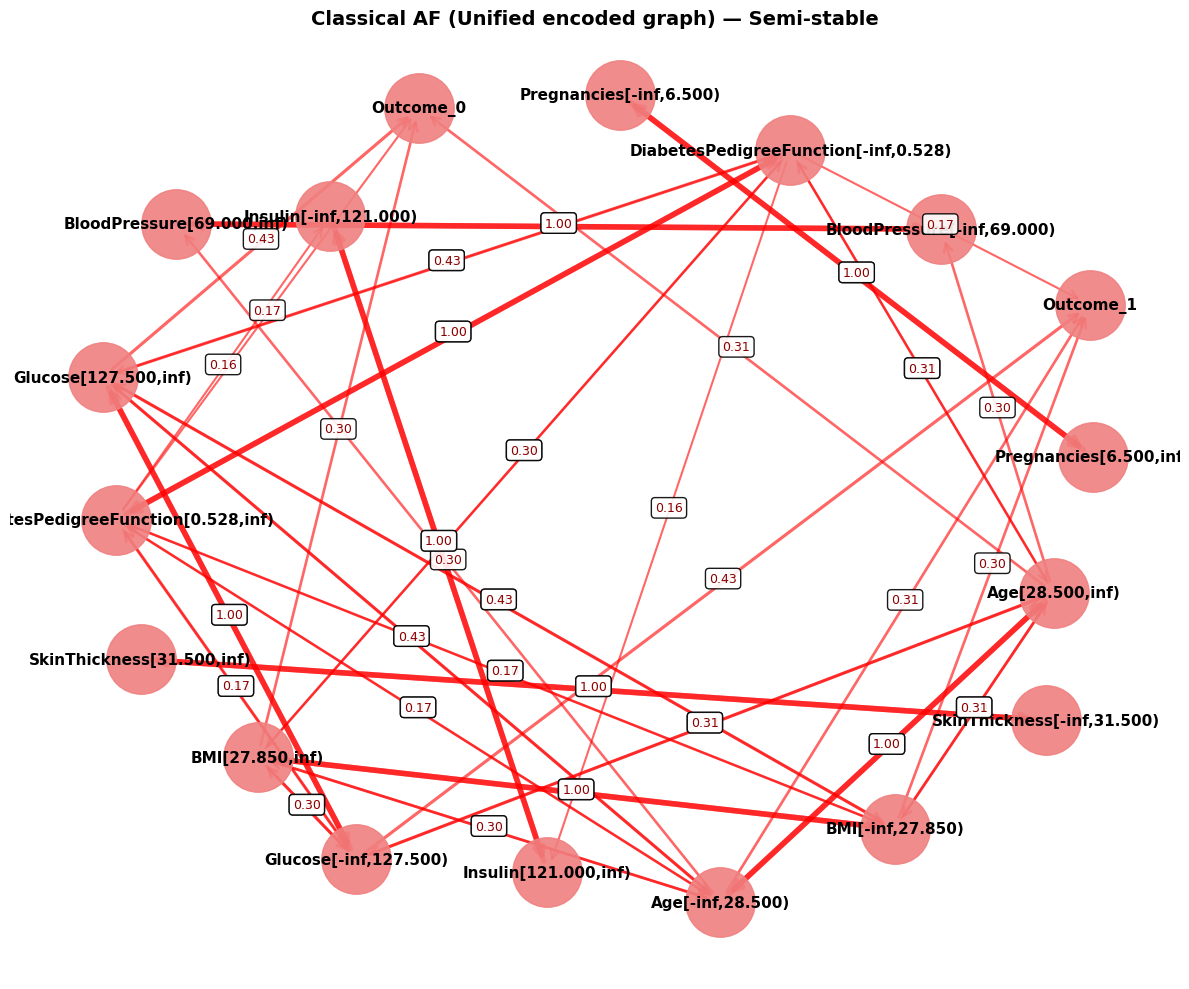

Saved filtered AF visualization to: outputs_diabetes/fci_experiment/classical_af_filtered.png


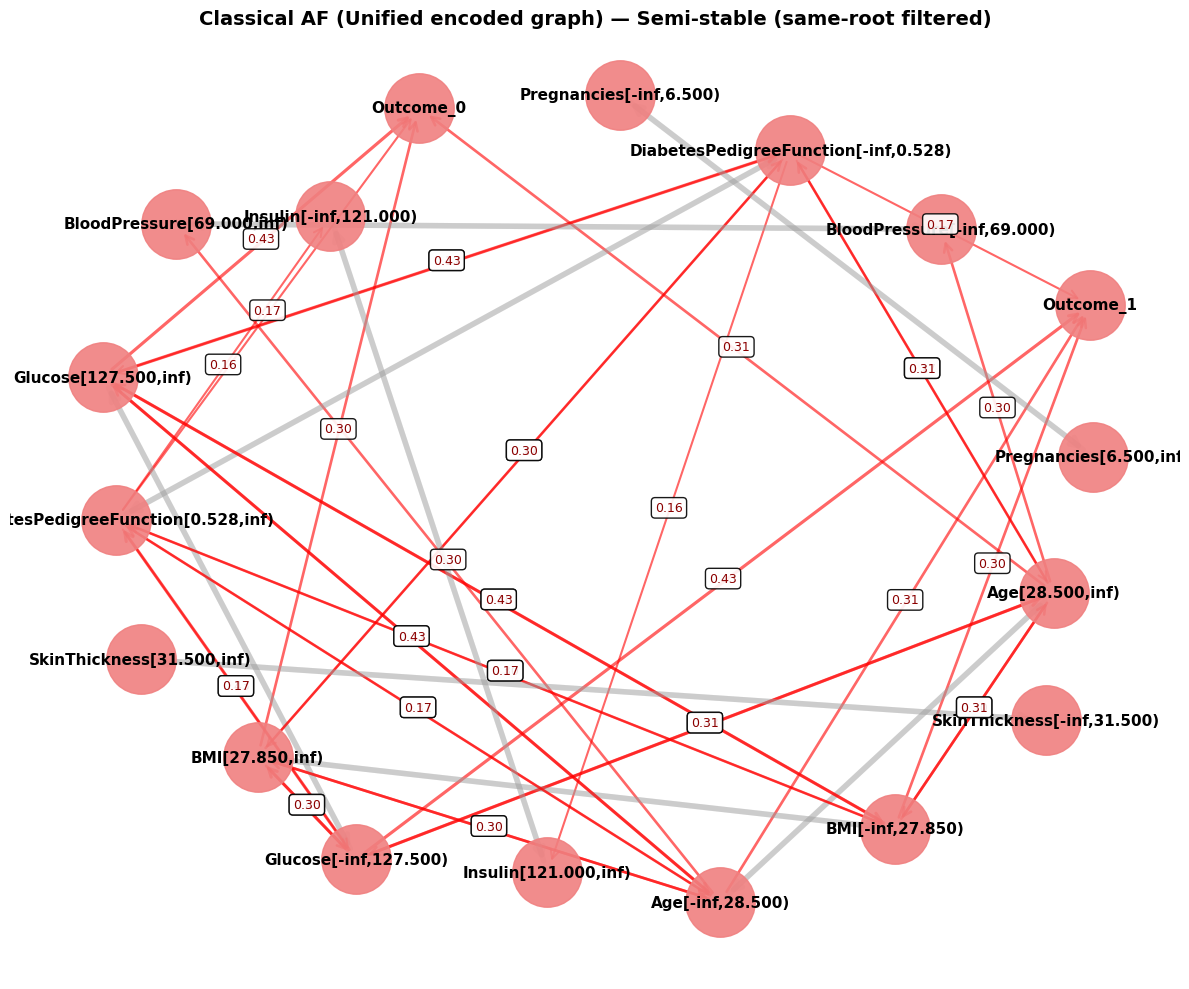

Exported APX format to: outputs_diabetes/fci_experiment/framework.apx
Exported TGF format to: outputs_diabetes/fci_experiment/framework.tgf
Saved: outputs_diabetes/fci_experiment/argument_acceptance.png


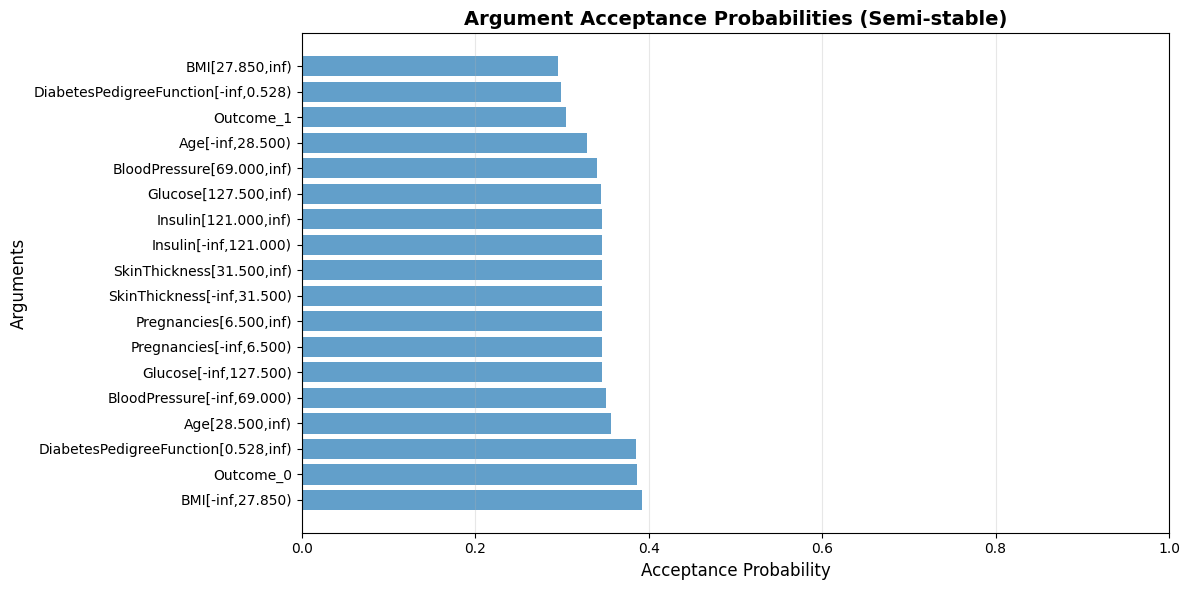

In [ ]:
import seaborn as sns
import os


OUTPUT_DIR = "outputs_diabetes/fci_experiment"
os.makedirs(OUTPUT_DIR, exist_ok=True)


df = pd.read_csv("diabetes.csv")
features = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
 ]
outcome = 'Outcome'
categorical_features = []  #


entropy_binning_config = {
    "features": features,
    "max_bins": 2,
    "min_gain": 0.005,
    "min_bin_size": 25
}
# Edit tiers to match your causal assumptions.
tier_groups = {
    1: ['Age', 'Pregnancies', 'DiabetesPedigreeFunction'],
    2: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI'],
    3: ['Outcome']
}
algo = "fci"    # or "pc"
alpha = 0.01
K_SPLITS = 5    # Number of K-folds you want to split into (can be changed to 3, 5, 10...)

print("=" * 60)
print(f"STEP 1: K-Fold BAF Discovery ({algo.upper()}) → Merge Orientations (majority)")
print("=" * 60)
merged_res, merged_group_edges, dfU, enc_groups_full = k_fold_baf_discovery(
    df,
    features,
    outcome,
    categorical_features,
    k_splits=K_SPLITS,
    entropy_binning_config=entropy_binning_config,
    binarize_counts=None,          
    algo=algo,
    alpha=alpha,
    merge_rule="majority",
    tier_groups=tier_groups,
    output_dir=OUTPUT_DIR,
    output_prefix="discovery"
 )
print(f"Merged group-level edges sau {K_SPLITS}-Fold: {sorted(list(merged_group_edges))}")


export_group_graph_with_corr(
    merged_group_edges,
    dfU,
    enc_groups_full,
    f"{OUTPUT_DIR}/merged_groups_{algo}_weighted.png",
    title=f"Merged Group Directions (K-Fold={K_SPLITS}, corr = strongest pair)"
 )

export_unified_graph_with_corr(
    merged_res,
    f"{OUTPUT_DIR}/final_unified_{algo}_weighted.png",
    title="Final Unified Encoded Graph (with correlations)"
 )

print("\n" + "=" * 60)
print("STEP 2: BAF on unified encoded graph (ALL dummies & bins)")
print("=" * 60)
baf = BAF(merged_res)
print(f"BAF: |Args|={len(baf.arguments)}  |Supp|={len(baf.supports)}  |Att|={len(baf.attacks)}")

print("\n" + "=" * 60)
print("STEP 3: Split sink into Outcome_0 and Outcome_1")
print("=" * 60)
# NOTE: sink name must match your outcome column
baf = make_binary_sink(baf, sink='Outcome', zero='Outcome_0', one='Outcome_1')

print("\n" + "=" * 60)
print("STEP 4: BAF → AF")
print("=" * 60)
af = baf.to_classical_af(
    threshold=0.05,
    enforce_exclusivity=True,
    exclusivity_skip=('Outcome',),   
    exclusivity_weight=1.0
 )
af.print_summary()

print("\n" + "=" * 60)
print("STEP 5: Semi-stable probabilistic extensions")
print("=" * 60)
# drop only the original outcome group (we just split it)
enc_groups_no_outcome = {g: cols for g, cols in enc_groups_full.items() if g != 'Outcome'}
# Include outcome group so enforce_group_exclusivity catches Outcome_0/Outcome_1 coexistence
enc_for_semantics = dict(enc_groups_no_outcome)
enc_for_semantics['Outcome'] = ['Outcome_0', 'Outcome_1']
extension_probs = af.compute_extensions_probability(
    semantics='semistable',
    top_k=50,
    threshold=0.25,
    require_one_of=('Outcome_0', 'Outcome_1'),
    exactly_one=False,
    enforce_group_exclusivity=True,
    encoding_groups=enc_for_semantics
 )

print("\n" + "=" * 60)
print("STEP 6: Argument acceptance")
print("=" * 60)
arg_acceptance = af.analyze_argument_acceptance(extension_probs)

print("\n" + "=" * 60)
print("STEP 7: Visualize & export")
print("=" * 60)
af.visualize(
    title="Classical AF (Unified encoded graph) — Semi-stable",
    output_file=f"{OUTPUT_DIR}/classical_af.png"
 )
af.visualize_filtered(
    title="Classical AF (Unified encoded graph) — Semi-stable (same-root filtered)",
    output_file=f"{OUTPUT_DIR}/classical_af_filtered.png",
    encoding_groups=baf.encoding_groups,
    same_root_alpha=0.3,
    drop_same_root=False
 )
af.to_apx_format(f"{OUTPUT_DIR}/framework.apx")
af.to_tgf_format(f"{OUTPUT_DIR}/framework.tgf")


plt.figure(figsize=(12, 6))
args_sorted = sorted(arg_acceptance.items(), key=lambda x: -x[1])
args_names = [a for a, _ in args_sorted]
args_probs = [p for _, p in args_sorted]
plt.barh(args_names, args_probs, alpha=0.7)
plt.xlabel('Acceptance Probability', fontsize=12)
plt.ylabel('Arguments', fontsize=12)
plt.title('Argument Acceptance Probabilities (Semi-stable)', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/argument_acceptance.png", dpi=150, bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/argument_acceptance.png")

### Diabetes — BAF Feature Ranking & RRF Comparison


In [ ]:
# ── Step A: BAF feature-level aggregation (Diabetes) ──
# NOTE: enc_groups_full and arg_acceptance here refer to the Diabetes run above
baf_ranking_diab = baf_feature_importance(
    arg_acceptance,
    enc_groups_full,
    outcome_name='Outcome',
    agg='max'
)
print('BAF Feature Ranking (Diabetes):')
for rank, (feat, score) in enumerate(baf_ranking_diab, 1):
    print(f'  {rank:2d}. {feat:35s} {score:.4f}')

# ── Save BAF ranking ──
OUTPUT_DIR_DIAB = 'outputs_diabetes/fci_experiment'
baf_df_diab = pd.DataFrame(baf_ranking_diab, columns=['Feature', 'BAF_Score'])
baf_df_diab['BAF_Rank'] = range(1, len(baf_df_diab) + 1)
baf_df_diab.to_csv(f'{OUTPUT_DIR_DIAB}/baf_feature_ranking.csv', index=False)
print(f'Saved: {OUTPUT_DIR_DIAB}/baf_feature_ranking.csv')


In [ ]:
# ── Step B: Load SHAP & LIME rankings for Diabetes ──
SIMPLE_OUTPUT_DIAB = 'outputs_diabetes'

shap_csv_diab = f'{SIMPLE_OUTPUT_DIAB}/shap_ranking.csv'
lime_csv_diab = f'{SIMPLE_OUTPUT_DIAB}/lime_global_ranking.csv'

if os.path.exists(shap_csv_diab) and os.path.exists(lime_csv_diab):
    shap_df_diab = pd.read_csv(shap_csv_diab)
    lime_df_diab = pd.read_csv(lime_csv_diab)

    shap_ranking_diab = list(zip(shap_df_diab['Feature'], shap_df_diab['SHAP_Score']))
    lime_ranking_diab = list(zip(lime_df_diab['Feature'], lime_df_diab['LIME_Score']))

    # ── RRF Fusion ──
    rrf_ranking_diab = reciprocal_rank_fusion(
        [baf_ranking_diab, shap_ranking_diab, lime_ranking_diab], k=60
    )
    print('RRF Fused Ranking (Diabetes):')
    for rank, (feat, score) in enumerate(rrf_ranking_diab, 1):
        print(f'  {rank:2d}. {feat:35s} {score:.6f}')

    rrf_df_diab = pd.DataFrame(rrf_ranking_diab, columns=['Feature', 'RRF_Score'])
    rrf_df_diab['RRF_Rank'] = range(1, len(rrf_df_diab) + 1)
    rrf_df_diab.to_csv(f'{OUTPUT_DIR_DIAB}/rrf_scores.csv', index=False)

    # ── Rank Comparison Table ──
    all_features_d = [f for f, _ in rrf_ranking_diab]

    baf_rank_map_d  = {f: i+1 for i, (f, _) in enumerate(baf_ranking_diab)}
    shap_rank_map_d = {f: i+1 for i, (f, _) in enumerate(shap_ranking_diab)}
    lime_rank_map_d = {f: i+1 for i, (f, _) in enumerate(lime_ranking_diab)}
    rrf_rank_map_d  = {f: i+1 for i, (f, _) in enumerate(rrf_ranking_diab)}
    n_feats_d = len(all_features_d) + 1

    rank_table_diab = pd.DataFrame({
        'BAF/AF': [baf_rank_map_d.get(f,  n_feats_d) for f in all_features_d],
        'SHAP':   [shap_rank_map_d.get(f, n_feats_d) for f in all_features_d],
        'LIME':   [lime_rank_map_d.get(f, n_feats_d) for f in all_features_d],
        'RRF':    [rrf_rank_map_d.get(f,  n_feats_d) for f in all_features_d],
    }, index=all_features_d)

    print('\nRank Comparison Table (Diabetes):')
    print(rank_table_diab.to_string())
    rank_table_diab.to_csv(f'{OUTPUT_DIR_DIAB}/rrf_rank_comparison.csv')

    # ── Heatmap & Bar Chart ──
    fig, axes = plt.subplots(1, 2, figsize=(18, max(5, len(all_features_d) * 0.55)))

    sns.heatmap(
        rank_table_diab,
        annot=True, fmt='d', cmap='RdYlGn_r',
        linewidths=0.5, ax=axes[0],
        cbar_kws={'label': 'Rank (lower = more important)'}
    )
    axes[0].set_title(
        'Feature Rank Comparison\nBAF/AF vs SHAP vs LIME (RRF Fusion)\n[Diabetes]',
        fontsize=12, fontweight='bold'
    )

    n_d = len(all_features_d)
    bar_df_d = pd.DataFrame({
        'BAF/AF': [(n_d + 1 - baf_rank_map_d.get(f, n_d+1)) / n_d for f in all_features_d],
        'SHAP':   [(n_d + 1 - shap_rank_map_d.get(f, n_d+1)) / n_d for f in all_features_d],
        'LIME':   [(n_d + 1 - lime_rank_map_d.get(f, n_d+1)) / n_d for f in all_features_d],
    }, index=all_features_d)
    bar_df_d.plot(kind='barh', ax=axes[1], colormap='Set2', edgecolor='white', linewidth=0.5)
    axes[1].set_title(
        'Relative Importance Score (normalized)\n[Diabetes]',
        fontsize=12, fontweight='bold'
    )
    axes[1].set_xlabel('Normalized Importance (higher = more important)')
    axes[1].invert_yaxis()
    axes[1].legend(loc='lower right')

    plt.tight_layout()
    out_img_d = f'{OUTPUT_DIR_DIAB}/rrf_rank_comparison.png'
    plt.savefig(out_img_d, dpi=150, bbox_inches='tight')
    print(f'Saved: {out_img_d}')
    plt.show()

else:
    print('SHAP/LIME CSVs not found yet. Run simple_workflow.ipynb first.')
    print(f'  Expected: {shap_csv_diab}')
    print(f'  Expected: {lime_csv_diab}')
